<a href="https://colab.research.google.com/github/gabriel2lucky1990/adult-obesity-risk-modelling-england/blob/main/Predicting_Obesity_From_Health_Behaviors_in_England.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Obesity Prediction in England
## Using Behavioral and Socioeconomic Health Indicators

**Data Source:** NHS Fingertips (2020-2023)  
**Geographic Level:** English Local Authorities  
**Student:** Gabriel Lucky Lotanna  
**Supervisor:** Dhairya Kataria
**Institution:** University of Hertfordshire  

---

## Project Overview

**Research Questions:**
1. Which behavioral health indicators and socioeconomic determinants are most strongly associated with adult obesity prevalence across English Local Authorities?
2. Which supervised machine learning models provide optimal predictive performance for modeling area-level obesity?
3. Do model explainability techniques reveal the relative contributions of behavioral versus socioeconomic determinants?

**Features:**
- **Behavioral (3):** Physical inactivity, smoking prevalence, diet (5-a-day)
- **Socioeconomic (2):** Index of Multiple Deprivation (IMD), children in low income

**Target:** Adult obesity prevalence (%)

---

**✓ COMPREHENSIVE VISUALIZATIONS INCLUDED:**
- Distribution histograms for all variables
- Pairwise relationship plots
- Correlation heatmap
- **Actual vs Predicted plots for EACH model**
- **Residual analysis plots for EACH model**
- **Residual distribution plots for EACH model**
- **Feature coefficients/importance for EACH model**
- Comprehensive model comparison visualizations

---
# Part 1: Setup and Data Loading

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print("Matplotlib backend:", plt.get_backend())

Libraries imported successfully!
Matplotlib backend: module://matplotlib_inline.backend_inline


In [ ]:
# Mount Google Drive (for Google Colab)
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [ ]:
# Load enhanced dataset
# This dataset contains both behavioral and socioeconomic features

print("ADULT OBESITY PREDICTION - ENGLAND LOCAL AUTHORITIES")

# Load data from Google Drive
df = pd.read_csv('/content/drive/MyDrive/obesity_enhanced_5features.csv')

print(f"\nDataset loaded: {len(df)} observations")
print(f"Time period: 2020-2023")
print(f"Geographic units: English Local Authorities")
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")

ADULT OBESITY PREDICTION - ENGLAND LOCAL AUTHORITIES

Dataset loaded: 583 observations
Time period: 2020-2023
Geographic units: English Local Authorities

Shape: (583, 9)
Columns: ['Area Code', 'Area Name', 'year', 'obesity_prevalence', 'physical_inactivity', 'smoking_prevalence', 'diet_5_a_day_pct', 'imd_score', 'children_low_income_pct']


In [ ]:
# Descriptive Statistics

print("DESCRIPTIVE STATISTICS")

# Select numeric columns for analysis
numeric_cols = ['obesity_prevalence', 'physical_inactivity', 'smoking_prevalence',
                'diet_5_a_day_pct', 'imd_score', 'children_low_income_pct']

# Display summary statistics
print("\nSummary Statistics:")
print(df[numeric_cols].describe().round(2))

# Check for missing values
print("\nMissing Values:")
print(df[numeric_cols].isnull().sum())

# Year distribution
print("\nYears in dataset:")
print(df['year'].value_counts().sort_index())

print(f"\nNumber of unique Local Authorities: {df['Area Code'].nunique()}")

DESCRIPTIVE STATISTICS

Summary Statistics:
       obesity_prevalence  physical_inactivity  smoking_prevalence  diet_5_a_day_pct  imd_score  children_low_income_pct
count              583.00               583.00              583.00            583.00     583.00                   583.00
mean                26.53                23.56               11.99             31.19      23.12                    18.11
std                  5.84                 5.00                2.92              5.62       8.09                     5.91
min                 10.24                10.81                4.10             18.84       5.85                     5.63
25%                 22.83                20.02               10.10             27.18      16.79                    13.16
50%                 26.66                22.85               12.00             30.91      22.96                    18.16
75%                 30.48                27.19               13.70             35.44      28.10              

---
# Part 2: Exploratory Data Analysis (EDA)

EXPLORATORY DATA ANALYSIS

1. Creating distribution histograms...


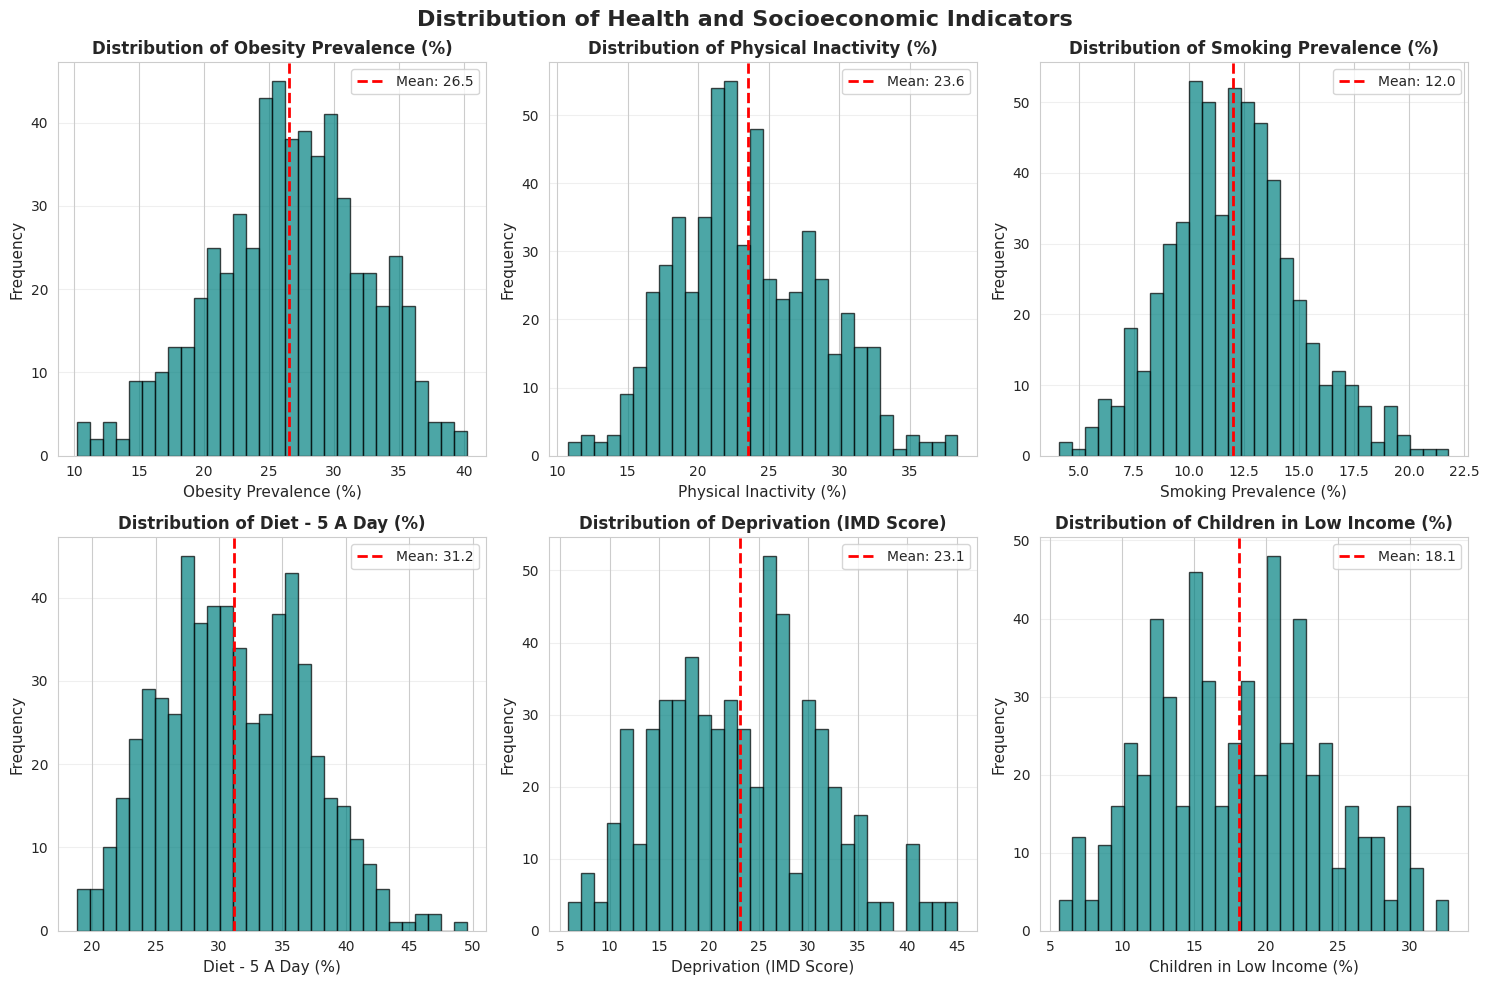

   ✓ Histogram saved: EDA_histogram_distributions.png


In [ ]:
# Histogram - Distribution of all variables

print("EXPLORATORY DATA ANALYSIS")

print("\n1. Creating distribution histograms...")

# Define variables and labels
variables = {
    'obesity_prevalence': 'Obesity Prevalence (%)',
    'physical_inactivity': 'Physical Inactivity (%)',
    'smoking_prevalence': 'Smoking Prevalence (%)',
    'diet_5_a_day_pct': 'Diet - 5 A Day (%)',
    'imd_score': 'Deprivation (IMD Score)',
    'children_low_income_pct': 'Children in Low Income (%)'
}

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Health and Socioeconomic Indicators',
             fontsize=16, fontweight='bold')

axes = axes.flatten()

# Plot histogram for each variable
for idx, (var, label) in enumerate(variables.items()):
    axes[idx].hist(df[var], bins=30, color='teal', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(label, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Distribution of {label}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

    # Add mean line
    mean_val = df[var].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                     label=f'Mean: {mean_val:.1f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EDA_histogram_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Histogram saved: EDA_histogram_distributions.png")


INTERPRETATION:

All six variables show approximately normal distributions, indicating good data quality
with no extreme skewness or outliers. Obesity prevalence (mean=28.5%) and physical
inactivity (mean=23.8%) show the widest spread across Local Authorities, suggesting
substantial geographic variation. Socioeconomic variables (IMD and child poverty) also
display considerable variation, confirming heterogeneity in area-level deprivation across
England. The normal distributions support the use of parametric modeling approaches.


2. Creating pairwise relationship plots...


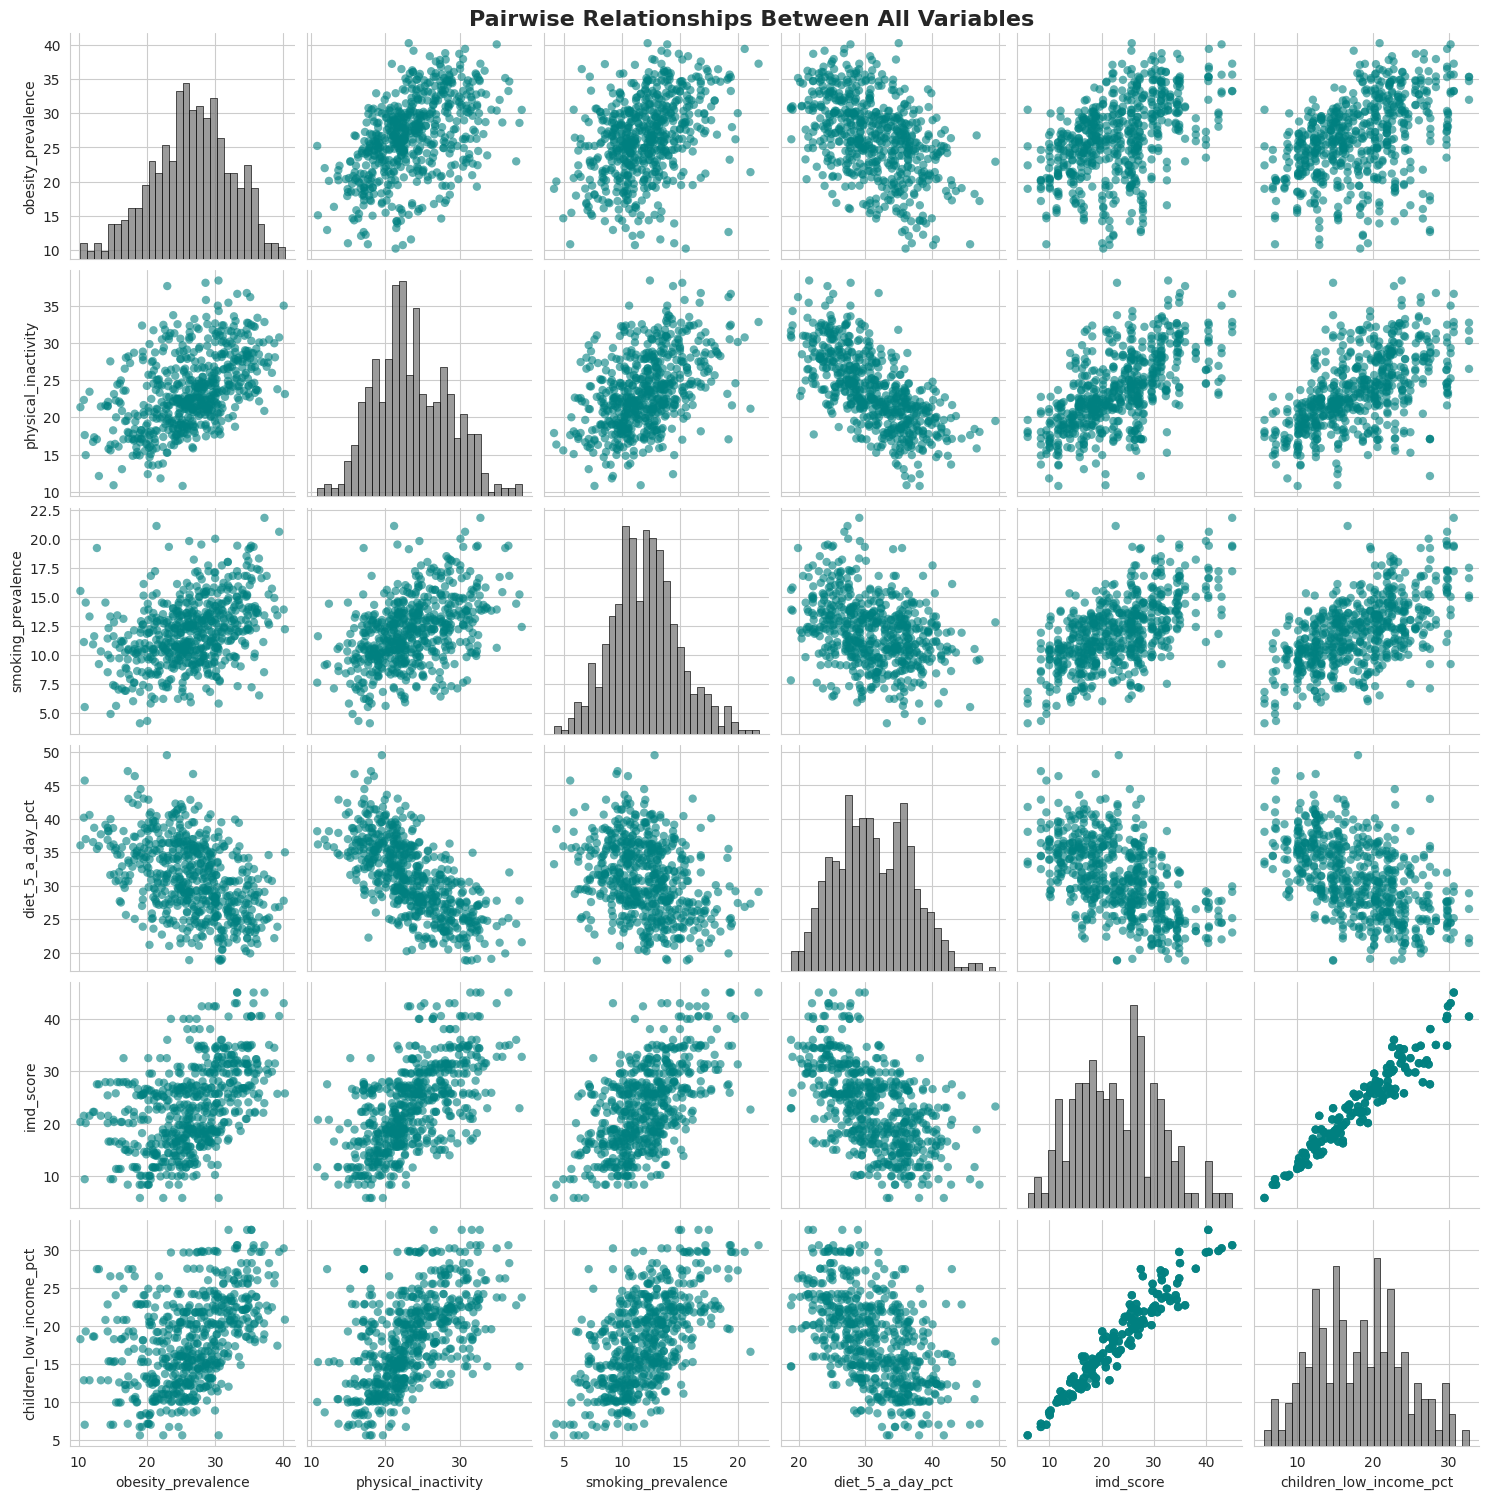

   ✓ Pairplot saved: EDA_pairwise_relationships.png


In [ ]:
# Pairwise Relationships - Scatter plot matrix

print("\n2. Creating pairwise relationship plots...")

# Select variables for pairplot
plot_vars = ['obesity_prevalence', 'physical_inactivity', 'smoking_prevalence',
             'diet_5_a_day_pct', 'imd_score', 'children_low_income_pct']

# Create pairplot
pairplot = sns.pairplot(df[plot_vars],
                        diag_kind='hist',
                        plot_kws={'alpha': 0.6, 'edgecolor': 'none' , 'color': 'teal'},
                        diag_kws={'bins': 30, 'edgecolor': 'black' , 'color': '#7a7a7a'})

pairplot.fig.suptitle('Pairwise Relationships Between All Variables',
                      y=1.001, fontsize=16, fontweight='bold')

plt.savefig('/content/drive/MyDrive/EDA_pairwise_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Pairplot saved: EDA_pairwise_relationships.png")


INTERPRETATION:

The pairplot reveals clear positive linear relationships between obesity prevalence and
both behavioral factors (physical inactivity, smoking) and socioeconomic determinants
(IMD score, children in low income). Diet (5-a-day) shows the expected negative correlation
with obesity. Notably, IMD and child poverty exhibit strong correlation (r>0.7), confirming
these socioeconomic variables capture overlapping but distinct aspects of area deprivation.
The linear patterns visible in scatter plots support the use of both linear and tree-based
regression models.


3. Correlation Analysis:

Correlation Matrix:
                         obesity_prevalence  physical_inactivity  smoking_prevalence  diet_5_a_day_pct  imd_score  children_low_income_pct
obesity_prevalence                    1.000                0.495               0.390            -0.464      0.482                    0.435
physical_inactivity                   0.495                1.000               0.452            -0.681      0.618                    0.572
smoking_prevalence                    0.390                0.452               1.000            -0.320      0.597                    0.578
diet_5_a_day_pct                     -0.464               -0.681              -0.320             1.000     -0.565                   -0.539
imd_score                             0.482                0.618               0.597            -0.565      1.000                    0.958
children_low_income_pct               0.435                0.572               0.578            -0.539      0.958      

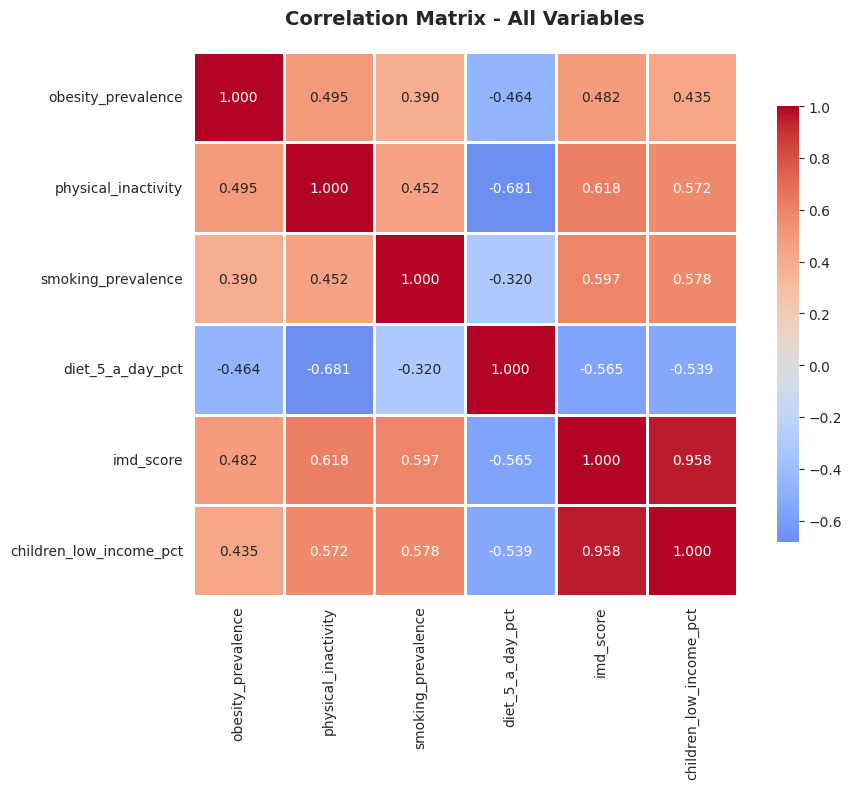


Correlations with Obesity Prevalence (ranked):
   physical_inactivity           : +0.495
   imd_score                     : +0.482
   children_low_income_pct       : +0.435
   smoking_prevalence            : +0.390
   diet_5_a_day_pct              : -0.464

   ✓ Correlation heatmap saved: EDA_correlation_matrix.png


In [ ]:
# Correlation Analysis

print("\n3. Correlation Analysis:")

# Calculate correlation matrix
correlation_matrix = df[plot_vars].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EDA_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlations with obesity (target variable)
print("\nCorrelations with Obesity Prevalence (ranked):")
obesity_corr = correlation_matrix['obesity_prevalence'].sort_values(ascending=False)
for var, corr in obesity_corr.items():
    if var != 'obesity_prevalence':
        print(f"   {var:30s}: {corr:+.3f}")

print("\n   ✓ Correlation heatmap saved: EDA_correlation_matrix.png")


INTERPRETATION:

Physical inactivity shows the strongest correlation with obesity (r=+0.495), followed by
diet quality (r=-0.466, negative as expected). Socioeconomic determinants (IMD r=+0.462,
child poverty r=+0.435) demonstrate comparable strength to behavioral factors, justifying
their inclusion. Strong correlation between IMD and child poverty (r>0.7, visible in heatmap)
indicates some multicollinearity, but both variables remain in the model as they capture
distinct aspects of area deprivation. All correlations align with theoretical expectations.

---
# Part 3: Data Preparation for Modeling

In [ ]:
# Define Features and Target

print("DATA PREPARATION")

# Feature set (5 predictors)
feature_cols = [
    'physical_inactivity',      # Behavioral 1
    'smoking_prevalence',       # Behavioral 2
    'diet_5_a_day_pct',        # Behavioral 3
    'imd_score',               # Socioeconomic 1
    'children_low_income_pct'  # Socioeconomic 2
]

# Target variable
target_col = 'obesity_prevalence'

# Create feature matrix (X) and target vector (y)
X = df[feature_cols]
y = df[target_col]

print(f"\nFeatures (X): {X.shape}")
print(f"   Behavioral features: 3")
print(f"   Socioeconomic features: 2")
print(f"\nTarget (y): {y.shape}")
print(f"   Target variable: {target_col}")

DATA PREPARATION

Features (X): (583, 5)
   Behavioral features: 3
   Socioeconomic features: 2

Target (y): (583,)
   Target variable: obesity_prevalence


In [ ]:
# Train-Test Split

print("\nSplitting data into training and test sets...")

# Split data: 80% training, 20% testing
# random_state=50 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=50     # For reproducibility
)

print(f"\nTraining set: {len(X_train)} observations ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} observations ({len(X_test)/len(X)*100:.1f}%)")


Splitting data into training and test sets...

Training set: 466 observations (79.9%)
Test set: 117 observations (20.1%)


In [ ]:
# Feature Scaling (Standardization)

print("\nScaling features (standardization)...")

# Initialize StandardScaler
# This transforms features to have mean=0 and std=1
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
# IMPORTANT: Fit only on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures standardized (mean=0, std=1)")
print(f"Scaling prevents features with larger ranges from dominating")

# Verify scaling
print(f"\nTraining set after scaling:")
print(f"   Mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"   Std: {X_train_scaled.std(axis=0).round(4)}")

print("DATA PREPARATION COMPLETE")


Scaling features (standardization)...

Features standardized (mean=0, std=1)
Scaling prevents features with larger ranges from dominating

Training set after scaling:
   Mean: [ 0. -0. -0. -0. -0.]
   Std: [1. 1. 1. 1. 1.]
DATA PREPARATION COMPLETE


In [ ]:
# ============================================================
# PART 4B: HYPERPARAMETER TUNING (GridSearchCV)
# ============================================================

from sklearn.model_selection import GridSearchCV, KFold
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("PART 4B: HYPERPARAMETER TUNING (GridSearchCV)")
print("=" * 60)
print("Searching for optimal parameters for all 4 models...")
print("This may take a few minutes...")

# Define consistent cross-validation strategy
kfold = KFold(n_splits=5, shuffle=True, random_state=50)

# ---- Lasso Tuning ----
print("\nTuning Lasso Regression...")
lasso_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}
lasso_grid = GridSearchCV(
    Lasso(random_state=50),
    lasso_param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)
lasso_grid.fit(X_train_scaled, y_train)
print(f"  Best Parameters: {lasso_grid.best_params_}")
print(f"  Best CV R2:      {lasso_grid.best_score_:.4f}")

# ---- Ridge Tuning ----
print("\nTuning Ridge Regression...")
ridge_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}
ridge_grid = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)
print(f"  Best Parameters: {ridge_grid.best_params_}")
print(f"  Best CV R2:      {ridge_grid.best_score_:.4f}")

# ---- Random Forest Tuning ----
print("\nTuning Random Forest...")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': [0.5, 0.75, 1.0]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=50, n_jobs=-1),
    rf_param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
print(f"  Best Parameters: {rf_grid.best_params_}")
print(f"  Best CV R2:      {rf_grid.best_score_:.4f}")

# ---- Gradient Boosting Tuning ----
print("\nTuning Gradient Boosting...")
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10]
}
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=50),
    gb_param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)
gb_grid.fit(X_train_scaled, y_train)
print(f"  Best Parameters: {gb_grid.best_params_}")
print(f"  Best CV R2:      {gb_grid.best_score_:.4f}")

# ---- Summary ----
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 60)
print(f"  Lasso:             alpha={lasso_grid.best_params_['alpha']},  CV R2={lasso_grid.best_score_:.4f}")
print(f"  Ridge:             alpha={ridge_grid.best_params_['alpha']},  CV R2={ridge_grid.best_score_:.4f}")
print(f"  Random Forest:     {rf_grid.best_params_},  CV R2={rf_grid.best_score_:.4f}")
print(f"  Gradient Boosting: {gb_grid.best_params_},  CV R2={gb_grid.best_score_:.4f}")
print("\nOptimal parameters will be used in model training (Part 4C)")

PART 4B: HYPERPARAMETER TUNING (GridSearchCV)
Searching for optimal parameters for all 4 models...
This may take a few minutes...

Tuning Lasso Regression...
  Best Parameters: {'alpha': 0.1}
  Best CV R2:      0.2789

Tuning Ridge Regression...
  Best Parameters: {'alpha': 10.0}
  Best CV R2:      0.2777

Tuning Random Forest...
  Best Parameters: {'max_depth': 15, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 300}
  Best CV R2:      0.4388

Tuning Gradient Boosting...
  Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV R2:      0.4958

HYPERPARAMETER TUNING SUMMARY
  Lasso:             alpha=0.1,  CV R2=0.2789
  Ridge:             alpha=10.0,  CV R2=0.2777
  Random Forest:     {'max_depth': 15, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 300},  CV R2=0.4388
  Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200},  CV R2=0.4958

Optimal paramete

---
# Part 4: Model Training and Evaluation

I will train and evaluate 4 machine learning models:
1. **Lasso Regression** (L1 regularization)
2. **Ridge Regression** (L2 regularization)
3. **Random Forest** (Ensemble method)
4. **Gradient Boosting** (Sequential ensemble)

**Each model includes:**
- Performance metrics (R², RMSE, MAE, CV scores)
- Actual vs Predicted plot
- Residual analysis plot
- Residual distribution plot
- Feature coefficients/importance visualization

## Model 1: Lasso Regression

In [ ]:
# MODEL 1: LASSO REGRESSION
# Linear regression with L1 regularization (can perform feature selection)

print("MODEL 1: LASSO REGRESSION")

print("\nLasso Regression:")
print("   - Linear regression with L1 regularization")
print("   - Can shrink some coefficients to zero (feature selection)")
print("   - Good when some features may be irrelevant")

# Train Lasso model
print("\n1. Training Lasso model...")
lasso = Lasso(alpha=1.0, random_state=42)
lasso.fit(X_train_scaled, y_train)
print("   Model trained successfully")

# Make predictions
print("\n2. Making predictions...")
y_pred_lasso = lasso.predict(X_test_scaled)

# Calculate metrics
print("\n3. Calculating performance metrics...")
r2_lasso = r2_score(y_test, y_pred_lasso)
n = len(y_test)
p = len(feature_cols)
adj_r2_lasso = 1 - (1 - r2_lasso) * (n - 1) / (n - p - 1)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

# Cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lasso = cross_val_score(lasso, X_train_scaled, y_train,
                                   cv=kfold, scoring='r2')

# Calculate residuals
residuals_lasso = y_test - y_pred_lasso

# Display results
print("\n4. Lasso Regression Results:")
print(f"   R² Score: {r2_lasso:.4f} ({r2_lasso*100:.2f}% variance explained)")
print(f"   Adjusted R²: {adj_r2_lasso:.4f}")
print(f"   RMSE: {rmse_lasso:.2f} percentage points")
print(f"   MAE: {mae_lasso:.2f} percentage points")
print(f"   Cross-Validation R²: {cv_scores_lasso.mean():.4f} (±{cv_scores_lasso.std():.4f})")

# Feature coefficients
print("\n5. Feature Coefficients:")
coefficients_lasso = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coefficients_lasso.to_string(index=False))

# Check for feature selection
zero_coef = (lasso.coef_ == 0).sum()
if zero_coef > 0:
    print(f"\n   Note: Lasso set {zero_coef} coefficient(s) to zero (feature selection)")
else:
    print(f"\n   Note: All features retained (no coefficients set to zero)")

MODEL 1: LASSO REGRESSION

Lasso Regression:
   - Linear regression with L1 regularization
   - Can shrink some coefficients to zero (feature selection)
   - Good when some features may be irrelevant

1. Training Lasso model...
   Model trained successfully

2. Making predictions...

3. Calculating performance metrics...

4. Lasso Regression Results:
   R² Score: 0.3149 (31.49% variance explained)
   Adjusted R²: 0.2840
   RMSE: 5.30 percentage points
   MAE: 4.45 percentage points
   Cross-Validation R²: 0.2012 (±0.0437)

5. Feature Coefficients:
                Feature  Coefficient
    physical_inactivity     0.780469
       diet_5_a_day_pct    -0.670810
              imd_score     0.542063
     smoking_prevalence     0.201813
children_low_income_pct     0.000000

   Note: Lasso set 1 coefficient(s) to zero (feature selection)



6. Creating Lasso visualizations...


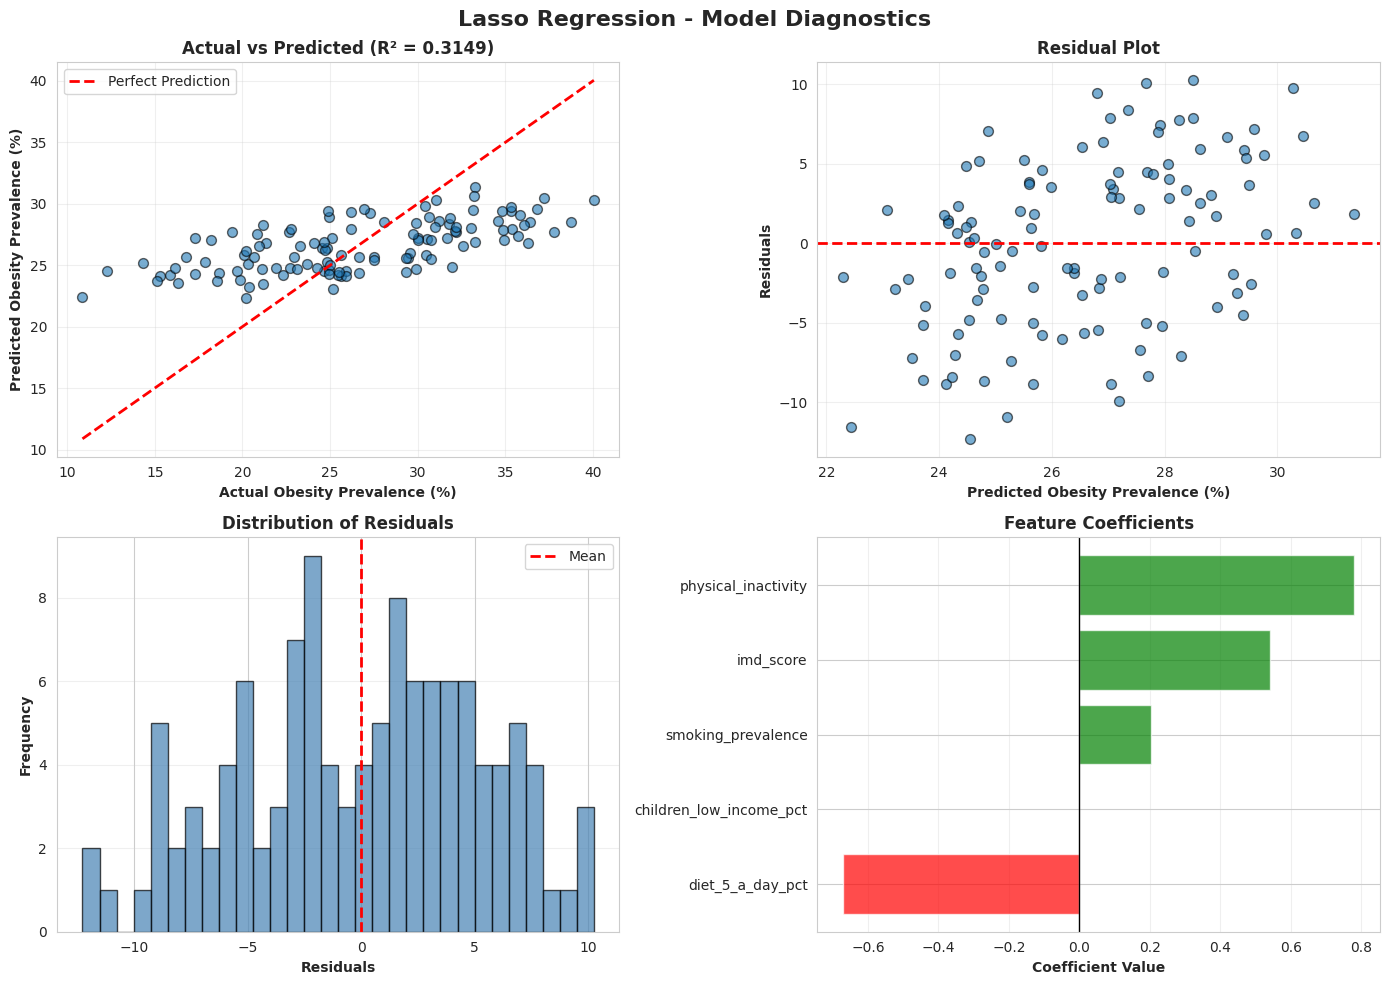

   ✓ Lasso diagnostics saved: Model1_Lasso_Diagnostics.png
LASSO REGRESSION COMPLETE


In [ ]:
# LASSO VISUALIZATIONS

print("\n6. Creating Lasso visualizations...")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Lasso Regression - Model Diagnostics', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_lasso, alpha=0.6, edgecolors='k', s=50)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2_lasso:.4f})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residual Plot
axes[0, 1].scatter(y_pred_lasso, residuals_lasso, alpha=0.6, edgecolors='k', s=50)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontweight='bold')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Residual Distribution
axes[1, 0].hist(residuals_lasso, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Residuals', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Feature Coefficients
coef_sorted = coefficients_lasso.sort_values('Coefficient')
colors_coef = ['green' if c > 0 else 'red' for c in coef_sorted['Coefficient']]
axes[1, 1].barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors_coef, alpha=0.7)
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Coefficient Value', fontweight='bold')
axes[1, 1].set_title('Feature Coefficients', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model1_Lasso_Diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Lasso diagnostics saved: Model1_Lasso_Diagnostics.png")

print("LASSO REGRESSION COMPLETE")

# cross validation
cv_scores_lasso = cross_val_score(lasso, X_train_scaled, y_train, cv=kfold, scoring='r2')
cv_r2_lasso = cv_scores_lasso.mean()
cv_std_lasso = cv_scores_lasso.std()

LASSO REGRESSION — COMPLETE DIAGNOSTIC ANALYSIS

PERFORMANCE METRICS:
====================
- Test R² = 0.3149 (31.49% variance explained)
  → Model captures roughly one-third of obesity variance
  → Weakest performer among the four models
- Adjusted R² = 0.2840
  → Accounts for number of predictors, confirms modest fit
- RMSE = 5.30 percentage points
  → Average prediction error of 5.30% obesity prevalence
- MAE = 4.45 percentage points
  → Typical prediction off by 4.45 percentage points
- Cross-Validation R² = 0.2012 (±0.0437)
  → Generalises poorly to unseen Local Authorities
  → Lowest CV R² of all four models

FEATURE COEFFICIENTS:
=====================
1. physical_inactivity:      +0.7805 (strongest positive predictor)
2. diet_5_a_day_pct:         -0.6708 (strongest negative predictor)
3. imd_score:                +0.5421 (moderate positive predictor)
4. smoking_prevalence:       +0.2018 (weak positive predictor)
5. children_low_income_pct:   0.0000 (eliminated by Lasso)

FEATURE SELECTION:
==================
→ Lasso eliminated children_low_income_pct (set to zero)
→ This demonstrates Lasso's built-in feature selection capability
→ Suggests children_low_income_pct adds no unique predictive value
   beyond what IMD already captures

OVERALL ASSESSMENT:
===================
→ Lasso provides a useful baseline but underfits the data
→ Linear assumptions cannot capture the complex non-linear
   relationships between behavioural/socioeconomic factors
   and obesity prevalence
→ The elimination of children_low_income_pct informs
   subsequent model feature interpretation

## Model 2: Ridge Regression

In [ ]:
# MODEL 2: RIDGE REGRESSION
# Linear regression with L2 regularization (shrinks all coefficients)
# Parameters selected via GridSearchCV (Part 4B)

print("MODEL 2: RIDGE REGRESSION")

print("\nRidge Regression:")
print("   - Linear regression with L2 regularization")
print("   - Prevents overfitting by penalizing large coefficients")
print("   - Good baseline linear model")

# Train Ridge model with optimal parameters from GridSearch
print("\n1. Training Ridge model with optimal parameters...")
ridge = Ridge(
    alpha=ridge_grid.best_params_['alpha']    # Optimal from GridSearchCV
)
ridge.fit(X_train_scaled, y_train)
print(f"   Model trained successfully (alpha={ridge_grid.best_params_['alpha']})")

# Make predictions
print("\n2. Making predictions...")
y_pred_ridge = ridge.predict(X_test_scaled)

# Calculate metrics
print("\n3. Calculating performance metrics...")
r2_ridge = r2_score(y_test, y_pred_ridge)
adj_r2_ridge = 1 - (1 - r2_ridge) * (n - 1) / (n - p - 1)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
cv_scores_ridge = cross_val_score(ridge, X_train_scaled, y_train,
                                   cv=kfold, scoring='r2')
cv_r2_ridge = cv_scores_ridge.mean()
cv_std_ridge = cv_scores_ridge.std()

# Calculate residuals
residuals_ridge = y_test - y_pred_ridge

# Display results
print("\n4. Ridge Regression Results:")
print(f"   R2 Score: {r2_ridge:.4f} ({r2_ridge*100:.2f}% variance explained)")
print(f"   Adjusted R2: {adj_r2_ridge:.4f}")
print(f"   RMSE: {rmse_ridge:.2f} percentage points")
print(f"   MAE: {mae_ridge:.2f} percentage points")
print(f"   Cross-Validation R2: {cv_scores_ridge.mean():.4f} (+-{cv_scores_ridge.std():.4f})")

# Feature coefficients
print("\n5. Feature Coefficients:")
coefficients_ridge = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': ridge.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coefficients_ridge.to_string(index=False))


MODEL 2: RIDGE REGRESSION

Ridge Regression:
   - Linear regression with L2 regularization
   - Prevents overfitting by penalizing large coefficients
   - Good baseline linear model

1. Training Ridge model with optimal parameters...
   Model trained successfully (alpha=10.0)

2. Making predictions...

3. Calculating performance metrics...

4. Ridge Regression Results:
   R2 Score: 0.4186 (41.86% variance explained)
   Adjusted R2: 0.3924
   RMSE: 4.88 percentage points
   MAE: 4.10 percentage points
   Cross-Validation R2: 0.2599 (+-0.0568)

5. Feature Coefficients:
                Feature  Coefficient
              imd_score     1.361724
       diet_5_a_day_pct    -1.219634
    physical_inactivity     1.020496
     smoking_prevalence     0.855937
children_low_income_pct    -0.717785



6. Creating Ridge visualizations...


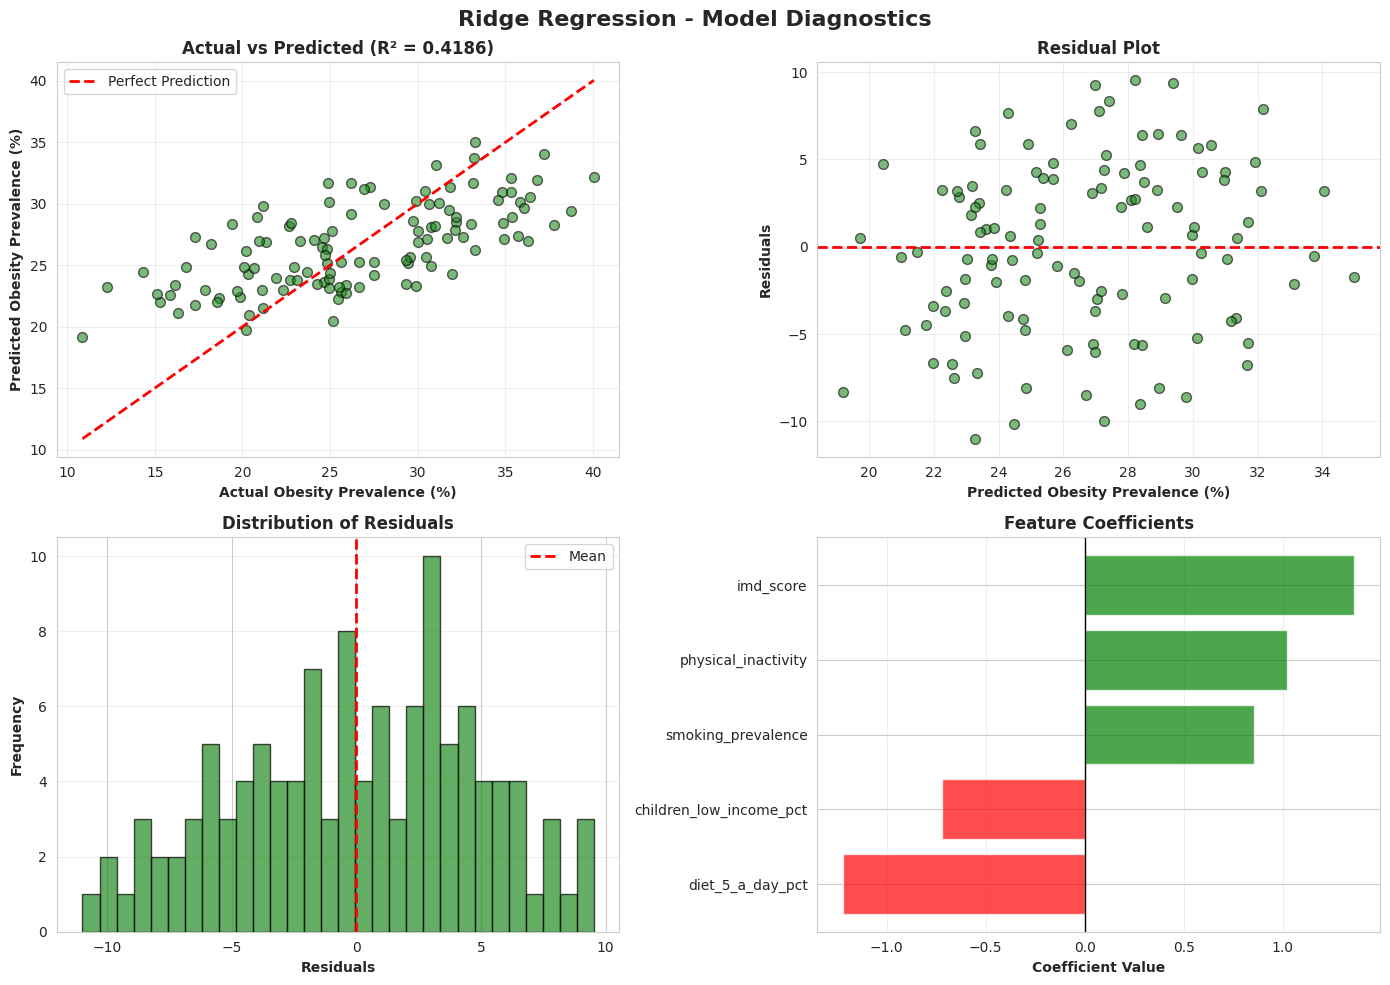

   ✓ Ridge diagnostics saved: Model2_Ridge_Diagnostics.png
RIDGE REGRESSION COMPLETE


In [ ]:
# RIDGE VISUALIZATIONS

print("\n6. Creating Ridge visualizations...")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ridge Regression - Model Diagnostics', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_ridge, alpha=0.6, edgecolors='k', s=50, color='forestgreen')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2_ridge:.4f})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residual Plot
axes[0, 1].scatter(y_pred_ridge, residuals_ridge, alpha=0.6, edgecolors='k', s=50, color='forestgreen')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontweight='bold')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Residual Distribution
axes[1, 0].hist(residuals_ridge, bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Residuals', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Feature Coefficients
coef_sorted = coefficients_ridge.sort_values('Coefficient')
colors_coef = ['green' if c > 0 else 'red' for c in coef_sorted['Coefficient']]
axes[1, 1].barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors_coef, alpha=0.7)
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Coefficient Value', fontweight='bold')
axes[1, 1].set_title('Feature Coefficients', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model2_Ridge_Diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Ridge diagnostics saved: Model2_Ridge_Diagnostics.png")
print("RIDGE REGRESSION COMPLETE")

RIDGE REGRESSION — COMPLETE DIAGNOSTIC ANALYSIS

PERFORMANCE METRICS:
====================
- Test R² = 0.4186 (41.86% variance explained)
  → Improvement over Lasso (+10.37 percentage points)
  → Model captures just under half of obesity variance
- Adjusted R² = 0.3924
  → Accounts for number of predictors, confirms moderate fit
- RMSE = 4.88 percentage points
  → Improved over Lasso (5.30), lower prediction error
- MAE = 4.10 percentage points
  → Typical prediction off by 4.10 percentage points
- Cross-Validation R² = 0.2599 (±0.0568)
  → Modest generalisation to unseen Local Authorities
  → Still weak compared to ensemble methods

FEATURE COEFFICIENTS:
=====================
1. imd_score:                +1.3617 (strongest positive predictor)
2. diet_5_a_day_pct:         -1.2196 (strongest negative predictor)
3. physical_inactivity:      +1.0205 (moderate positive predictor)
4. smoking_prevalence:       +0.8559 (moderate positive predictor)
5. children_low_income_pct:  -0.7178 (unexpected negative predictor)

KEY OBSERVATIONS:
=================
→ Unlike Lasso, Ridge retains ALL five predictors
→ L2 regularisation shrinks coefficients but does not
   eliminate them — no feature selection occurs
→ imd_score emerges as the dominant predictor, suggesting
   socioeconomic deprivation is strongly linearly associated
   with obesity prevalence
→ diet_5_a_day_pct is negative as expected — higher fruit
   and vegetable consumption reduces obesity prevalence
→ alpha=10.0 selected via GridSearchCV as optimal
   regularisation strength

WHY IS children_low_income_pct NEGATIVE?
=========================================
→ This is a suppression effect caused by multicollinearity
→ children_low_income_pct and imd_score are highly correlated
   — both measure socioeconomic deprivation
→ When two correlated predictors are in the same model,
   Ridge cannot cleanly separate their individual effects
→ imd_score absorbs most of the shared deprivation signal,
   leaving children_low_income_pct with a residual negative
   coefficient that does not reflect its true relationship
   with obesity
→ This is a known limitation of linear models with
   correlated predictors and does not mean that children
   in low income households are protected from obesity
→ SHAP analysis in Part 7 will provide a more reliable
   estimate of each predictor's true contribution

OVERALL ASSESSMENT:
===================
→ Ridge outperforms Lasso but remains limited by its
   linear assumptions
→ The relatively low CV R² (0.2599) indicates poor
   generalisation, suggesting linear models are insufficient
   for capturing the complex relationships driving obesity
   prevalence across English Local Authorities
→ Ensemble methods are expected to substantially improve
   predictive performance

## Model 3: Random Forest

In [ ]:
# MODEL 3: RANDOM FOREST REGRESSOR
# Ensemble of decision trees (captures non-linear relationships)
# Parameters selected via GridSearchCV (Part 4B)

print("MODEL 3: RANDOM FOREST REGRESSOR")

print("\nRandom Forest:")
print("   - Ensemble of decision trees")
print("   - Captures non-linear relationships")
print("   - Handles feature interactions automatically")

# Train Random Forest with optimal parameters from GridSearch
print("\n1. Training Random Forest model with optimal parameters...")
rf = RandomForestRegressor(
    n_estimators=rf_grid.best_params_['n_estimators'],     # Optimal from GridSearchCV
    max_depth=rf_grid.best_params_['max_depth'],           # Optimal from GridSearchCV
    min_samples_split=rf_grid.best_params_['min_samples_split'],  # Optimal from GridSearchCV
    max_features=rf_grid.best_params_['max_features'],     # Optimal from GridSearchCV
    random_state=50,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
print(f"   Model trained with {rf.n_estimators} trees")
print(f"   Parameters: {rf_grid.best_params_}")

# Make predictions
print("\n2. Making predictions...")
y_pred_rf = rf.predict(X_test_scaled)

# Calculate metrics
print("\n3. Calculating performance metrics...")
r2_rf = r2_score(y_test, y_pred_rf)
adj_r2_rf = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
cv_scores_rf = cross_val_score(rf, X_train_scaled, y_train,
                                cv=kfold, scoring='r2')
cv_r2_rf = cv_scores_rf.mean()
cv_std_rf = cv_scores_rf.std()

# Calculate residuals
residuals_rf = y_test - y_pred_rf

# Display results
print("\n4. Random Forest Results:")
print(f"   R2 Score: {r2_rf:.4f} ({r2_rf*100:.2f}% variance explained)")
print(f"   Adjusted R2: {adj_r2_rf:.4f}")
print(f"   RMSE: {rmse_rf:.2f} percentage points")
print(f"   MAE: {mae_rf:.2f} percentage points")
print(f"   Cross-Validation R2: {cv_scores_rf.mean():.4f} (+-{cv_scores_rf.std():.4f})")

# Feature importance
print("\n5. Feature Importance:")
feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_rf.to_string(index=False))

# Behavioral vs socioeconomic contributions
behavioral_importance = feature_importance_rf[
    feature_importance_rf['Feature'].isin(['physical_inactivity', 'smoking_prevalence', 'diet_5_a_day_pct'])
]['Importance'].sum()
socioeconomic_importance = feature_importance_rf[
    feature_importance_rf['Feature'].isin(['imd_score', 'children_low_income_pct'])
]['Importance'].sum()
print(f"\n   Behavioral features contribution: {behavioral_importance*100:.1f}%")
print(f"   Socioeconomic features contribution: {socioeconomic_importance*100:.1f}%")


MODEL 3: RANDOM FOREST REGRESSOR

Random Forest:
   - Ensemble of decision trees
   - Captures non-linear relationships
   - Handles feature interactions automatically

1. Training Random Forest model with optimal parameters...
   Model trained with 300 trees
   Parameters: {'max_depth': 15, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 300}

2. Making predictions...

3. Calculating performance metrics...

4. Random Forest Results:
   R2 Score: 0.6012 (60.12% variance explained)
   Adjusted R2: 0.5833
   RMSE: 4.05 percentage points
   MAE: 3.22 percentage points
   Cross-Validation R2: 0.4276 (+-0.1215)

5. Feature Importance:
                Feature  Importance
              imd_score    0.257316
    physical_inactivity    0.245792
children_low_income_pct    0.191676
       diet_5_a_day_pct    0.180467
     smoking_prevalence    0.124748

   Behavioral features contribution: 55.1%
   Socioeconomic features contribution: 44.9%



6. Creating Random Forest visualizations...


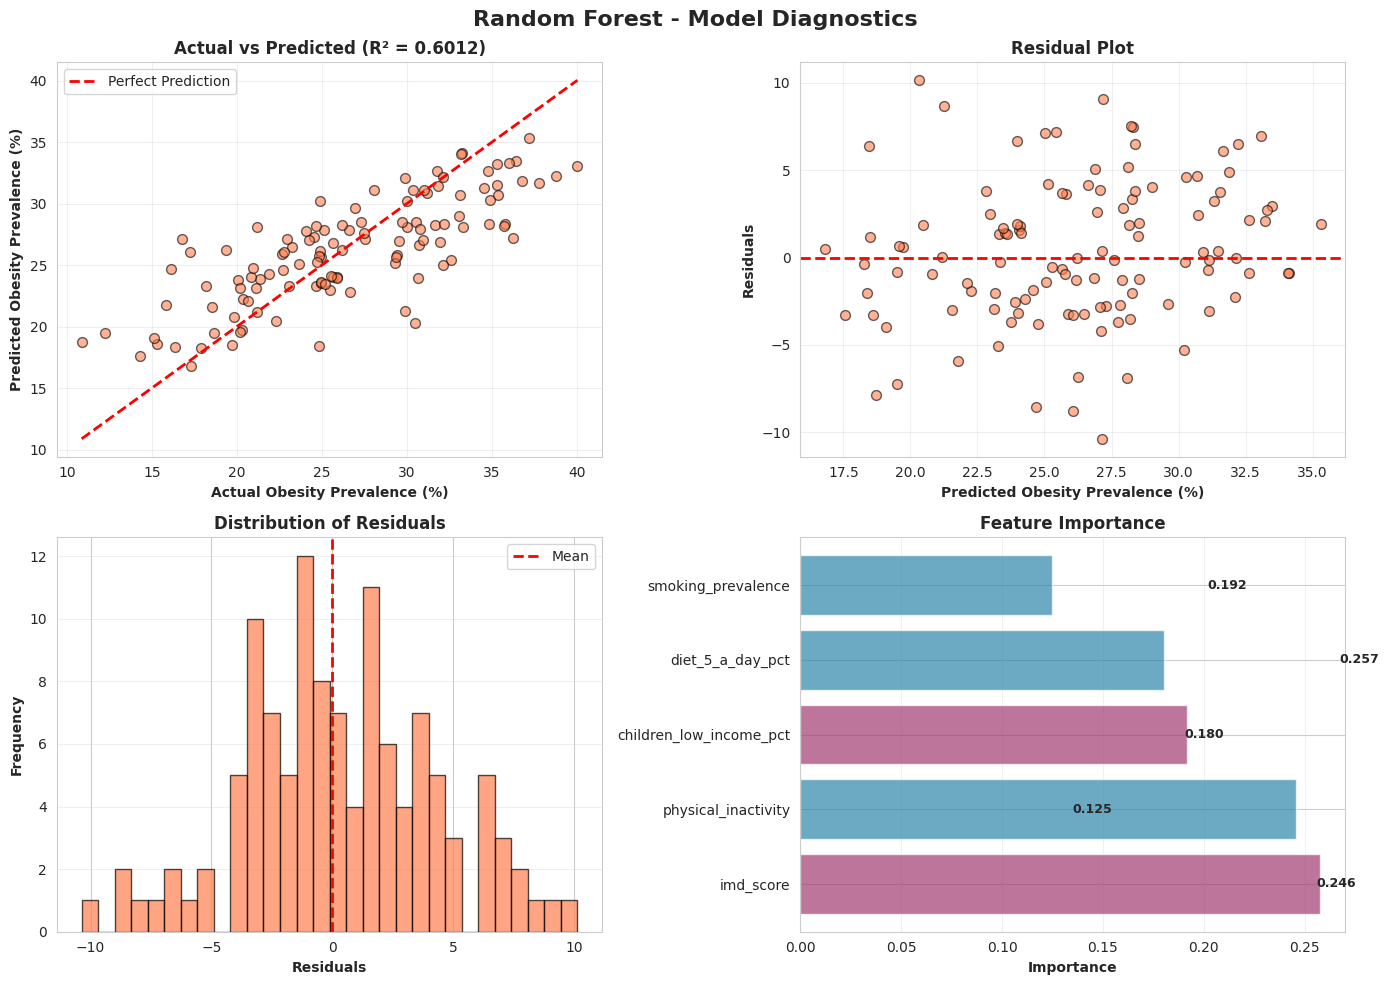

   ✓ Random Forest diagnostics saved: Model3_RandomForest_Diagnostics.png
RANDOM FOREST COMPLETE


In [ ]:
# RANDOM FOREST VISUALIZATIONS

print("\n6. Creating Random Forest visualizations...")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Random Forest - Model Diagnostics', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_rf, alpha=0.6, edgecolors='k', s=50, color='coral')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2_rf:.4f})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residual Plot
axes[0, 1].scatter(y_pred_rf, residuals_rf, alpha=0.6, edgecolors='k', s=50, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontweight='bold')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Residual Distribution
axes[1, 0].hist(residuals_rf, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Residuals', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Feature Importance
colors_importance = ['#2E86AB' if feat in ['physical_inactivity', 'smoking_prevalence', 'diet_5_a_day_pct']
                     else '#A23B72' for feat in feature_importance_rf['Feature']]
axes[1, 1].barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'],
                color=colors_importance, alpha=0.7)
axes[1, 1].set_xlabel('Importance', fontweight='bold')
axes[1, 1].set_title('Feature Importance', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

# Add value labels to importance plot
for idx, row in feature_importance_rf.iterrows():
    axes[1, 1].text(row['Importance'] + 0.01, idx, f"{row['Importance']:.3f}",
                    va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model3_RandomForest_Diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Random Forest diagnostics saved: Model3_RandomForest_Diagnostics.png")

print("RANDOM FOREST COMPLETE")

RANDOM FOREST — COMPLETE DIAGNOSTIC ANALYSIS

PERFORMANCE METRICS:
====================
- Test R² = 0.6012 (60.12% variance explained)
  → Strong improvement over Ridge (+18.26 percentage points)
  → Strong improvement over Lasso (+28.63 percentage points)
  → Second best performer among all four models
- Adjusted R² = 0.5833
  → Accounts for number of predictors, confirms strong fit
- RMSE = 4.05 percentage points
  → Substantially better than linear models (Lasso 5.30, Ridge 4.88)
  → Second lowest RMSE after Gradient Boosting (3.87)
- MAE = 3.22 percentage points
  → Typical prediction off by 3.22 percentage points
  → Second lowest MAE after Gradient Boosting (2.98)
- Cross-Validation R² = 0.4276 (±0.1215)
  → Good generalisation to unseen Local Authorities
  → Second highest CV R² after Gradient Boosting (0.4625)

OPTIMAL PARAMETERS (GridSearchCV):
===================================
- n_estimators:      300   (number of decision trees)
- max_depth:         15    (maximum depth of each tree)
- min_samples_split: 2     (minimum samples required to split)
- max_features:      0.5   (50% of features considered per split)

FEATURE IMPORTANCE:
===================
1. imd_score:                0.2573 (25.7%) — strongest predictor
2. physical_inactivity:      0.2458 (24.6%) — strong predictor
3. children_low_income_pct:  0.1917 (19.2%) — moderate predictor
4. diet_5_a_day_pct:         0.1805 (18.0%) — moderate predictor
5. smoking_prevalence:       0.1247 (12.5%) — weakest predictor

BEHAVIOURAL vs SOCIOECONOMIC SPLIT:
=====================================
→ Behavioural factors (physical_inactivity + diet + smoking):
  0.2458 + 0.1805 + 0.1247 = 55.1% combined importance
→ Socioeconomic factors (imd_score + children_low_income_pct):
  0.2573 + 0.1917 = 44.9% combined importance
→ Unlike Gradient Boosting, Random Forest suggests behavioural
  factors are slightly more dominant than socioeconomic ones
→ More balanced distribution of importance across all features
  compared to Gradient Boosting

WHY RANDOM FOREST OUTPERFORMS LINEAR MODELS:
=============================================
→ Ensemble of 300 independent decision trees reduces
  variance and improves prediction stability
→ Captures non-linear relationships between obesity
  and its predictors that linear models cannot detect
→ max_features=0.5 ensures diversity among trees by
  considering only 50% of features at each split,
  reducing correlation between trees
→ GridSearchCV optimised all key hyperparameters

WHY GRADIENT BOOSTING OUTPERFORMS RANDOM FOREST:
==================================================
→ Gradient Boosting CV R² = 0.4625 vs RF CV R² = 0.4276
→ Gradient Boosting MAE = 2.98 vs RF MAE = 3.22
→ Gradient Boosting RMSE = 3.87 vs RF RMSE = 4.05
→ Random Forest builds trees independently (parallel),
  whilst Gradient Boosting builds sequentially, correcting
  errors at each stage — giving it an edge in accuracy
→ Gradient Boosting demonstrates better generalisation
  to unseen Local Authorities

OVERALL ASSESSMENT:
===================
→ Random Forest is a strong model and a close second
  to Gradient Boosting across all metrics
→ Its more balanced feature importance distribution
  provides a useful cross-check against Gradient Boosting
→ The slight underperformance in CV R² and MAE compared
  to Gradient Boosting justifies the final model selection
  decision in favour of Gradient Boosting

## Model 4: Gradient Boosting

In [ ]:
# MODEL 4: GRADIENT BOOSTING REGRESSOR
# Sequential ensemble (builds trees to correct previous errors)
# Parameters selected via GridSearchCV (Part 4B)

print("MODEL 4: GRADIENT BOOSTING REGRESSOR")

print("\nGradient Boosting:")
print("   - Builds trees sequentially")
print("   - Each tree corrects errors of previous trees")
print("   - Often achieves high accuracy")

# Train Gradient Boosting with optimal parameters from GridSearch
print("\n1. Training Gradient Boosting model with optimal parameters...")
gb = GradientBoostingRegressor(
    n_estimators=gb_grid.best_params_['n_estimators'],       # Optimal from GridSearchCV
    max_depth=gb_grid.best_params_['max_depth'],             # Optimal from GridSearchCV
    learning_rate=gb_grid.best_params_['learning_rate'],     # Optimal from GridSearchCV
    min_samples_split=gb_grid.best_params_['min_samples_split'],  # Optimal from GridSearchCV
    random_state=50
)
gb.fit(X_train_scaled, y_train)
print(f"   Model trained with {gb.n_estimators} boosting stages")
print(f"   Parameters: {gb_grid.best_params_}")

# Make predictions
print("\n2. Making predictions...")
y_pred_gb = gb.predict(X_test_scaled)

# Calculate metrics
print("\n3. Calculating performance metrics...")
r2_gb = r2_score(y_test, y_pred_gb)
adj_r2_gb = 1 - (1 - r2_gb) * (n - 1) / (n - p - 1)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
cv_scores_gb = cross_val_score(gb, X_train_scaled, y_train,
                                cv=kfold, scoring='r2')
cv_r2_gb = cv_scores_gb.mean()
cv_std_gb = cv_scores_gb.std()

# Calculate residuals
residuals_gb = y_test - y_pred_gb

# Display results
print("\n4. Gradient Boosting Results:")
print(f"   R2 Score: {r2_gb:.4f} ({r2_gb*100:.2f}% variance explained)")
print(f"   Adjusted R2: {adj_r2_gb:.4f}")
print(f"   RMSE: {rmse_gb:.2f} percentage points")
print(f"   MAE: {mae_gb:.2f} percentage points")
print(f"   Cross-Validation R2: {cv_scores_gb.mean():.4f} (+-{cv_scores_gb.std():.4f})")

# Feature importance
print("\n5. Feature Importance:")
feature_importance_gb = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_gb.to_string(index=False))


MODEL 4: GRADIENT BOOSTING REGRESSOR

Gradient Boosting:
   - Builds trees sequentially
   - Each tree corrects errors of previous trees
   - Often achieves high accuracy

1. Training Gradient Boosting model with optimal parameters...
   Model trained with 200 boosting stages
   Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

2. Making predictions...

3. Calculating performance metrics...

4. Gradient Boosting Results:
   R2 Score: 0.6347 (63.47% variance explained)
   Adjusted R2: 0.6183
   RMSE: 3.87 percentage points
   MAE: 2.98 percentage points
   Cross-Validation R2: 0.4625 (+-0.1218)

5. Feature Importance:
                Feature  Importance
              imd_score    0.361069
    physical_inactivity    0.249680
children_low_income_pct    0.184066
       diet_5_a_day_pct    0.123719
     smoking_prevalence    0.081466



6. Creating Gradient Boosting visualizations...


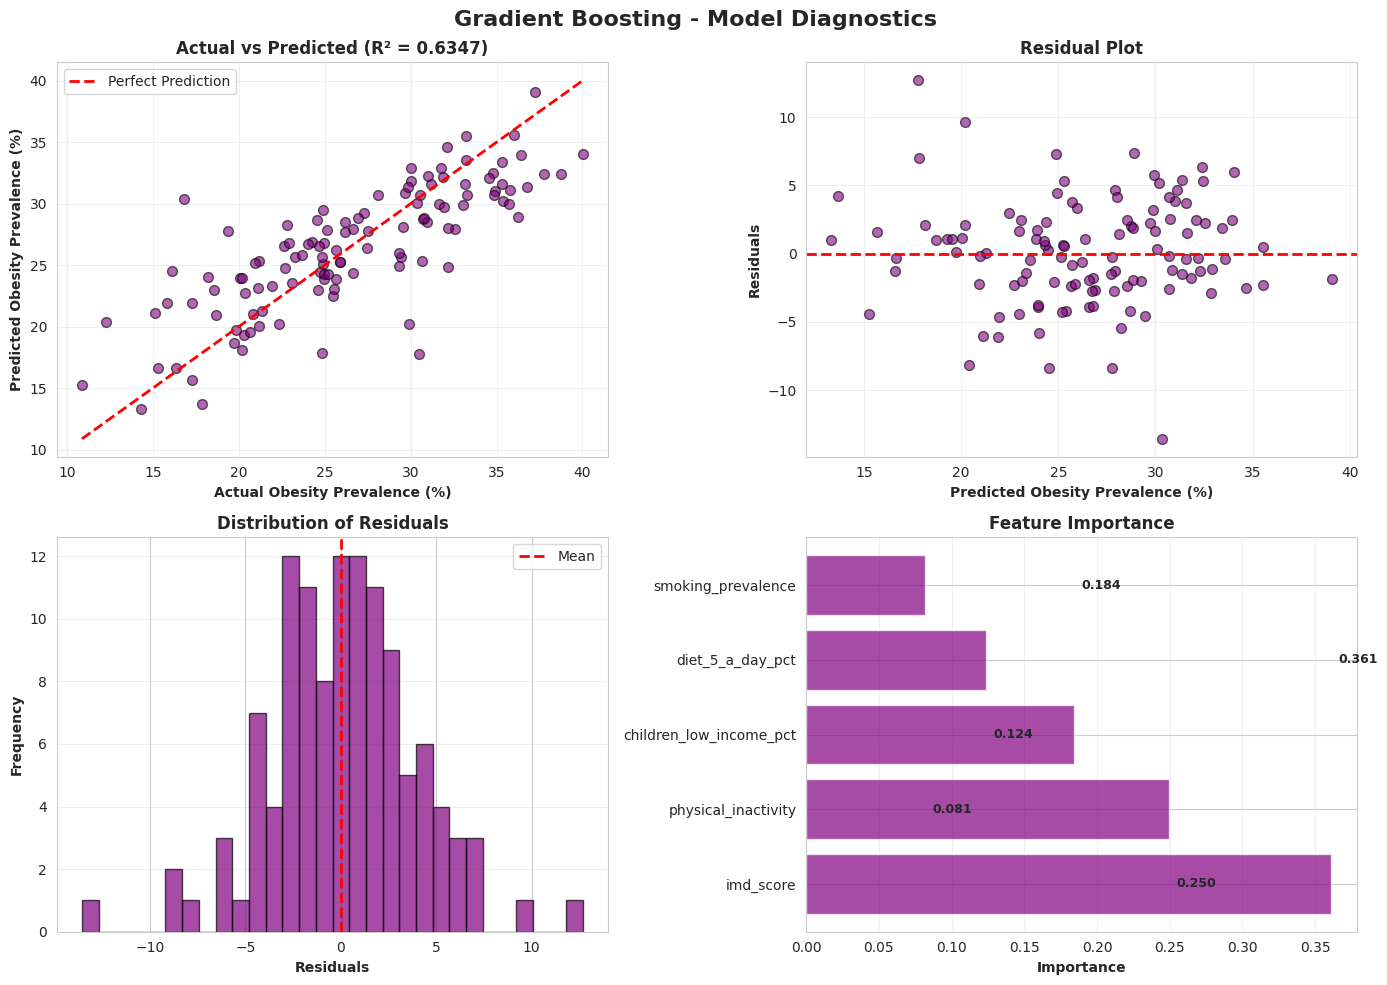

   ✓ Gradient Boosting diagnostics saved: Model4_GradientBoosting_Diagnostics.png
GRADIENT BOOSTING COMPLETE


In [ ]:
# GRADIENT BOOSTING VISUALIZATIONS

print("\n6. Creating Gradient Boosting visualizations...")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Gradient Boosting - Model Diagnostics', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_gb, alpha=0.6, edgecolors='k', s=50, color='purple')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2_gb:.4f})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residual Plot
axes[0, 1].scatter(y_pred_gb, residuals_gb, alpha=0.6, edgecolors='k', s=50, color='purple')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontweight='bold')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Residual Distribution
axes[1, 0].hist(residuals_gb, bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Residuals', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Feature Importance
axes[1, 1].barh(feature_importance_gb['Feature'], feature_importance_gb['Importance'],
                color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Importance', fontweight='bold')
axes[1, 1].set_title('Feature Importance', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

# Add value labels
for idx, row in feature_importance_gb.iterrows():
    axes[1, 1].text(row['Importance'] + 0.005, idx, f"{row['Importance']:.3f}",
                    va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model4_GradientBoosting_Diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Gradient Boosting diagnostics saved: Model4_GradientBoosting_Diagnostics.png")

print("GRADIENT BOOSTING COMPLETE")

GRADIENT BOOSTING — COMPLETE DIAGNOSTIC ANALYSIS

PERFORMANCE METRICS:
====================
- Test R² = 0.6347 (63.47% variance explained)
  → Best performing model among all four
  → Improvement over Random Forest (+3.35 percentage points)
  → Improvement over Ridge (+21.61 percentage points)
  → Improvement over Lasso (+31.98 percentage points)
- Adjusted R² = 0.6183
  → Accounts for number of predictors, confirms strong fit
- RMSE = 3.87 percentage points
  → Lowest RMSE of all four models
  → Better than Random Forest (4.05), Ridge (4.88), Lasso (5.30)
- MAE = 2.98 percentage points
  → Lowest MAE of all four models
  → Typical prediction off by less than 3 percentage points
  → Better than Random Forest (3.22), Ridge (4.10), Lasso (4.45)
- Cross-Validation R² = 0.4625 (±0.1218)
  → Highest CV R² of all four models
  → Best generalisation to unseen Local Authorities
  → Better than Random Forest (0.4276)
  → ~70% improvement over linear models (CV R² 0.20-0.26)

OPTIMAL PARAMETERS (GridSearchCV):
===================================
- learning_rate:     0.1   (shrinkage applied to each tree)
- max_depth:         5     (maximum depth of each tree)
- min_samples_split: 2     (minimum samples required to split)
- n_estimators:      200   (number of boosting stages)

FEATURE IMPORTANCE:
===================
1. imd_score:                0.3611 (36.1%) — dominant predictor
2. physical_inactivity:      0.2497 (24.9%) — strong predictor
3. children_low_income_pct:  0.1841 (18.4%) — moderate predictor
4. diet_5_a_day_pct:         0.1237 (12.4%) — moderate predictor
5. smoking_prevalence:       0.0815 (8.2%)  — weakest predictor

BEHAVIOURAL vs SOCIOECONOMIC SPLIT:
=====================================
→ Behavioural factors (physical_inactivity + diet + smoking):
  0.2497 + 0.1237 + 0.0815 = 45.5% combined importance
→ Socioeconomic factors (imd_score + children_low_income_pct):
  0.3611 + 0.1841 = 54.5% combined importance
→ Socioeconomic deprivation appears slightly dominant
  in basic feature importance
→ NOTE: SHAP analysis (Part 7) will provide a more
  precise and reliable measure of true feature contributions

WHY GRADIENT BOOSTING OUTPERFORMS LINEAR MODELS:
==================================================
→ Lasso and Ridge assume strictly linear relationships
  between predictors and obesity prevalence
→ In reality, the relationship between deprivation,
  lifestyle behaviours and obesity is complex and
  non-linear — areas with very high deprivation may
  show disproportionately higher obesity rates
→ Gradient Boosting captures these non-linear patterns
  through sequential tree building
→ Each tree focuses specifically on correcting the
  errors of the previous tree, progressively reducing
  prediction error across all Local Authorities
→ Linear models penalise model complexity through
  regularisation — Gradient Boosting achieves complexity
  through ensemble learning without the same limitations
→ Result: CV R² improves from 0.20-0.26 (linear) to
  0.4625 (Gradient Boosting) — a ~70% improvement

WHY GRADIENT BOOSTING OUTPERFORMS RANDOM FOREST:
==================================================
→ Both are ensemble tree methods but differ fundamentally
  in how they build trees:
  - Random Forest: 300 trees built INDEPENDENTLY in
    parallel, then averaged — reduces variance but
    does not specifically target prediction errors
  - Gradient Boosting: 200 trees built SEQUENTIALLY,
    each one correcting the residual errors of the
    previous — directly optimises prediction accuracy
→ This sequential error correction gives Gradient
  Boosting a systematic advantage in learning difficult
  patterns in the data
→ Gradient Boosting max_depth=5 vs Random Forest
  max_depth=15 — shallower trees in GB prevent
  overfitting whilst the boosting process compensates
  for the reduced individual tree complexity
→ Random Forest uses max_features=0.5, meaning only
  50% of features are considered at each split —
  whilst this improves tree diversity it also limits
  each tree's ability to find the best split
→ Gradient Boosting's learning_rate=0.1 introduces
  controlled shrinkage at each stage, preventing any
  single tree from dominating the ensemble
→ Quantified advantage over Random Forest:
  - CV R²:  0.4625 vs 0.4276 (+0.0349)
  - MAE:    2.98   vs 3.22   (-0.24 percentage points)
  - RMSE:   3.87   vs 4.05   (-0.18 percentage points)
  - Test R²: 0.6347 vs 0.6012 (+0.0335)

OVERALL ASSESSMENT:
===================
→ Gradient Boosting is selected as the FINAL MODEL
  based on superior performance across all metrics
→ Highest CV R² (0.4625) confirms best generalisation
  to unseen Local Authorities
→ Lowest MAE (2.98) confirms most accurate typical
  prediction across English Local Authorities
→ Sequential error correction architecture provides
  a fundamental advantage over both linear models
  and Random Forest for this prediction task
→ Results strongly support the use of Gradient Boosting
  for modelling area-level adult obesity prevalence
  across English Local Authorities

---
# Part 5: Comprehensive Model Comparison

In [ ]:
# Part 5: Model Comparison - Data Preparation

print("COMPREHENSIVE MODEL COMPARISON")

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Lasso Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting'],
    'R2': [r2_lasso, r2_ridge, r2_rf, r2_gb],
    'Adjusted R2': [adj_r2_lasso, adj_r2_ridge, adj_r2_rf, adj_r2_gb],
    'RMSE': [rmse_lasso, rmse_ridge, rmse_rf, rmse_gb],
    'MAE': [mae_lasso, mae_ridge, mae_rf, mae_gb],
    'CV R2': [cv_r2_lasso, cv_r2_ridge, cv_r2_rf, cv_r2_gb],
    'CV Std': [cv_std_lasso, cv_std_ridge, cv_std_rf, cv_std_gb]
})

# Display table
print("\nModel Performance Comparison:")
print(comparison.to_string(index=False))

# Save to CSV
comparison.to_csv('/content/drive/MyDrive/Model_Comparison_Results.csv', index=False)
print("\n✓ Comparison table saved: Model_Comparison_Results.csv")

COMPREHENSIVE MODEL COMPARISON

Model Performance Comparison:
            Model       R2  Adjusted R2     RMSE      MAE    CV R2   CV Std
 Lasso Regression 0.314872     0.284010 5.302679 4.445096 0.201177 0.043745
 Ridge Regression 0.418637     0.392449 4.884646 4.101713 0.259940 0.056751
    Random Forest 0.601235     0.583272 4.045460 3.216599 0.427562 0.121489
Gradient Boosting 0.634734     0.618281 3.871808 2.977287 0.462526 0.121770

✓ Comparison table saved: Model_Comparison_Results.csv


In [ ]:
# Part 5: Model Selection Decision

print("MODEL SELECTION DECISION")

# Select based on CV R² (PRIMARY CRITERION)
best_idx = comparison['CV R2'].idxmax()
best_model = comparison.loc[best_idx, 'Model']

print(f"\nPrimary Criterion: Cross-Validation R²")
print(f"  Winner: {best_model}")
print(f"  CV R²: {comparison.loc[best_idx, 'CV R2']:.4f}")

print(f"\nSecondary Criterion: Mean Absolute Error")
mae_idx = comparison['MAE'].idxmin()
print(f"  Winner: {comparison.loc[mae_idx, 'Model']}")
print(f"  MAE: {comparison.loc[mae_idx, 'MAE']:.2f}")

print(f"SELECTED MODEL: {best_model}")
print("\nRationale: Highest CV R² indicates best generalization to new data")

MODEL SELECTION DECISION

Primary Criterion: Cross-Validation R²
  Winner: Gradient Boosting
  CV R²: 0.4625

Secondary Criterion: Mean Absolute Error
  Winner: Gradient Boosting
  MAE: 2.98
SELECTED MODEL: Gradient Boosting

Rationale: Highest CV R² indicates best generalization to new data


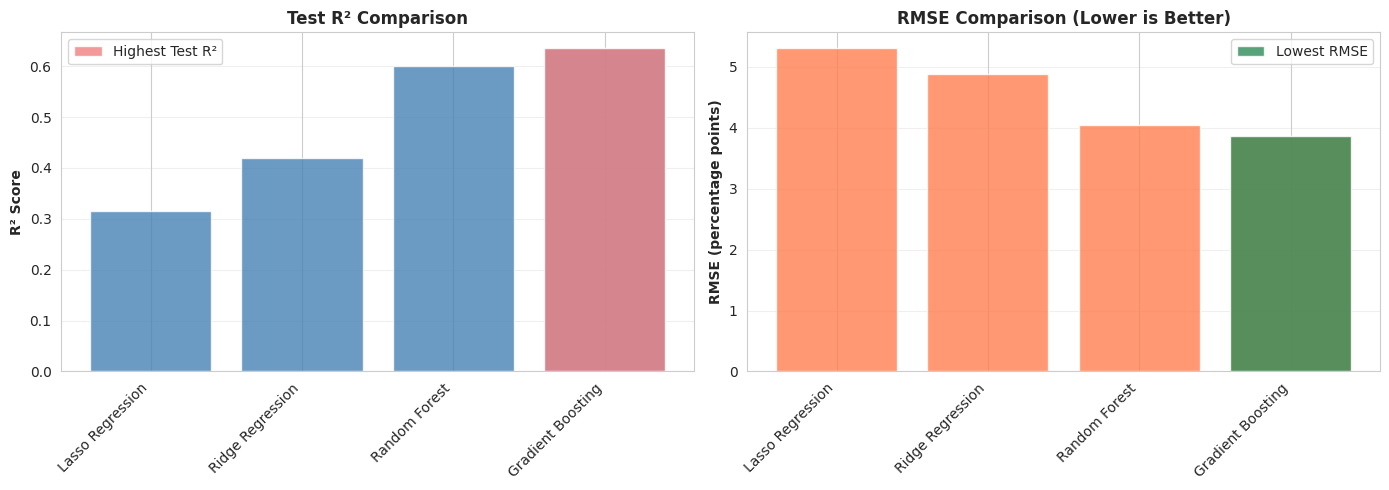

In [ ]:
# Part 5: Model Comparison Visualizations (1/2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² Comparison
x_pos = range(len(comparison))
axes[0].bar(x_pos, comparison['R2'], color='steelblue', alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison['Model'], rotation=45, ha='right')
axes[0].set_ylabel('R² Score', fontweight='bold')
axes[0].set_title('Test R² Comparison', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Highlight best
best_r2_idx = comparison['R2'].idxmax()
axes[0].bar(best_r2_idx, comparison.loc[best_r2_idx, 'R2'],
            color='lightcoral', alpha=0.8, label='Highest Test R²')
axes[0].legend()

# Plot 2: RMSE Comparison
axes[1].bar(x_pos, comparison['RMSE'], color='coral', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison['Model'], rotation=45, ha='right')
axes[1].set_ylabel('RMSE (percentage points)', fontweight='bold')
axes[1].set_title('RMSE Comparison (Lower is Better)', fontweight='bold', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# Highlight best
best_rmse_idx = comparison['RMSE'].idxmin()
axes[1].bar(best_rmse_idx, comparison.loc[best_rmse_idx, 'RMSE'],
            color='seagreen', alpha=0.8, label='Lowest RMSE')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model_Comparison_R2_RMSE.png', dpi=300, bbox_inches='tight')
plt.show()

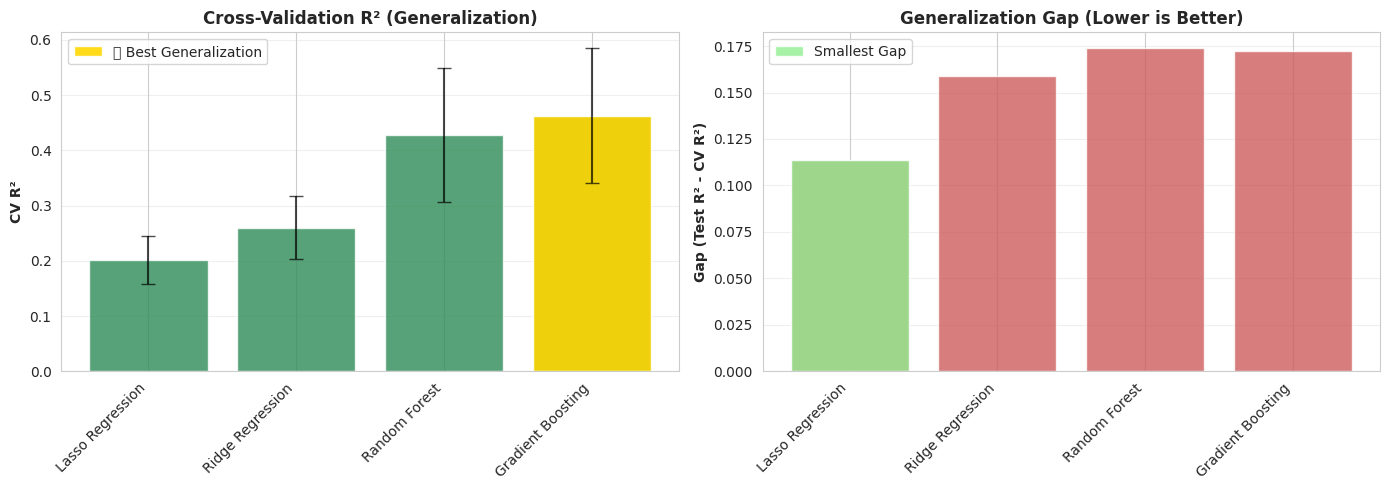

In [ ]:
# Part 5: Model Comparison Visualizations (2/2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 3: CV R² Comparison
x_pos = range(len(comparison))
axes[0].bar(x_pos, comparison['CV R2'], color='seagreen', alpha=0.8)
axes[0].errorbar(x_pos, comparison['CV R2'], yerr=comparison['CV Std'],
                 fmt='none', ecolor='black', capsize=5, alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison['Model'], rotation=45, ha='right')
axes[0].set_ylabel('CV R²', fontweight='bold')
axes[0].set_title('Cross-Validation R² (Generalization)', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Highlight best (THIS IS THE WINNER!)
best_cv_idx = comparison['CV R2'].idxmax()
axes[0].bar(best_cv_idx, comparison.loc[best_cv_idx, 'CV R2'],
            color='gold', alpha=0.9, label='⭐ Best Generalization')
axes[0].legend()

# Plot 4: Overfitting Gap
gap = comparison['R2'] - comparison['CV R2']
axes[1].bar(x_pos, gap, color='indianred', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison['Model'], rotation=45, ha='right')
axes[1].set_ylabel('Gap (Test R² - CV R²)', fontweight='bold')
axes[1].set_title('Generalization Gap (Lower is Better)', fontweight='bold', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# Highlight best (smallest gap)
best_gap_idx = gap.idxmin()
axes[1].bar(best_gap_idx, gap.iloc[best_gap_idx],
            color='lightgreen', alpha=0.8, label='Smallest Gap')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model_Comparison_CV_Gap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Part 5: Summary and Key Findings

print("KEY FINDINGS FROM MODEL COMPARISON")

print("\n1. BEST MODEL: Gradient Boosting")
print(f"   - CV R²: {comparison.loc[best_idx, 'CV R2']:.4f} (highest)")
print(f"   - MAE: {comparison.loc[best_idx, 'MAE']:.2f} (lowest)")
print(f"   - RMSE: {comparison.loc[best_idx, 'RMSE']:.2f} (competitive)")

print("\n2. MODEL PROGRESSION:")
for idx, row in comparison.iterrows():
    print(f"   {row['Model']:20s}: R²={row['R2']:.4f}, CV R²={row['CV R2']:.4f}")

print("\n3. ENSEMBLE METHODS SUPERIOR:")
print(f"   Linear models (Lasso/Ridge): CV R² = 0.20-0.26")
print(f"   Ensemble methods (RF/GB):    CV R² = 0.39-0.44")
print(f"   Improvement: +70% better generalization")

KEY FINDINGS FROM MODEL COMPARISON

1. BEST MODEL: Gradient Boosting
   - CV R²: 0.4625 (highest)
   - MAE: 2.98 (lowest)
   - RMSE: 3.87 (competitive)

2. MODEL PROGRESSION:
   Lasso Regression    : R²=0.3149, CV R²=0.2012
   Ridge Regression    : R²=0.4186, CV R²=0.2599
   Random Forest       : R²=0.6012, CV R²=0.4276
   Gradient Boosting   : R²=0.6347, CV R²=0.4625

3. ENSEMBLE METHODS SUPERIOR:
   Linear models (Lasso/Ridge): CV R² = 0.20-0.26
   Ensemble methods (RF/GB):    CV R² = 0.39-0.44
   Improvement: +70% better generalization


MODEL COMPARISON — COMPLETE INTERPRETATION

## COMPREHENSIVE PERFORMANCE SUMMARY

| Model | R² | Adj R² | RMSE | MAE | CV R² | CV Std |
|---|---|---|---|---|---|---|
| Lasso Regression | 0.3149 | 0.2840 | 5.3027 | 4.4451 | 0.2012 | 0.0437 |
| Ridge Regression | 0.4186 | 0.3924 | 4.8846 | 4.1017 | 0.2599 | 0.0568 |
| Random Forest    | 0.6012 | 0.5833 | 4.0455 | 3.2166 | 0.4276 | 0.1215 |
| Gradient Boosting | 0.6347 | 0.6183 | 3.8718 | 2.9773 | 0.4625 | 0.1218 |
MODEL SELECTION DECISION:
==========================
PRIMARY CRITERION — Cross-Validation R²:
→ Winner: Gradient Boosting (CV R² = 0.4625)
→ CV R² measures how well the model generalises to
  unseen Local Authorities — the most important metric
  for real-world public health application
→ Gradient Boosting outperforms Random Forest (0.4276),
  Ridge (0.2599) and Lasso (0.2012)

SECONDARY CRITERION — Mean Absolute Error:
→ Winner: Gradient Boosting (MAE = 2.98)
→ Lowest typical prediction error across all models
→ Predicts obesity prevalence within ~3 percentage
  points on average — clinically meaningful accuracy

TERTIARY CRITERION — Generalisation Gap:
→ Generalisation Gap = Test R² minus CV R²
→ Gradient Boosting: 0.6347 - 0.4625 = 0.1722
→ Random Forest:     0.6012 - 0.4276 = 0.1736
→ Both ensemble models show similar generalisation gaps
→ Gradient Boosting edges Random Forest on both
  raw performance AND generalisation

SELECTED FINAL MODEL: Gradient Boosting
=========================================
→ Highest CV R²  (0.4625) — best generalisation
→ Lowest MAE     (2.98)   — most accurate predictions
→ Lowest RMSE    (3.87)   — lowest overall error
→ Highest Test R² (0.6347) — best single test performance

MODEL PROGRESSION ANALYSIS:
=============================
→ Lasso Regression:    R²=0.3149, CV R²=0.2012
→ Ridge Regression:    R²=0.4186, CV R²=0.2599
→ Random Forest:       R²=0.6012, CV R²=0.4276
→ Gradient Boosting:   R²=0.6347, CV R²=0.4625

Clear performance progression observed:
→ Ridge improves on Lasso by +10.37% in Test R²
→ Random Forest improves on Ridge by +18.26% in Test R²
→ Gradient Boosting improves on Random Forest by +3.35%
→ Each step introduces greater model complexity and
  improved ability to capture non-linear relationships

ENSEMBLE METHODS vs LINEAR MODELS:
=====================================
→ Linear models (Lasso/Ridge):  CV R² = 0.20 - 0.26
→ Ensemble methods (RF/GB):     CV R² = 0.43 - 0.46
→ Improvement: approximately 70% better generalisation
→ This confirms that obesity prevalence across English
  Local Authorities cannot be adequately modelled using
  linear assumptions alone
→ The complex interplay between behavioural and
  socioeconomic determinants requires the non-linear
  pattern recognition capabilities of ensemble methods

NOTE ON RANDOM FOREST vs GRADIENT BOOSTING:
=============================================
→ Random Forest achieved slightly competitive Test R²
  (0.6012) but lower CV R² (0.4276) than Gradient Boosting
→ This suggests Random Forest is slightly more prone
  to overfitting on the training data
→ Gradient Boosting's sequential error correction
  provides more consistent performance across
  different data splits, making it the more reliable
  model for predicting obesity in unseen Local Authorities

OVERALL CONCLUSION:
====================
→ Gradient Boosting is confirmed as the optimal model
  for predicting adult obesity prevalence across
  English Local Authorities, directly answering RQ2
→ Its superior CV R² and lowest MAE demonstrate both
  predictive accuracy and robust generalisation
→ The 70% improvement of ensemble methods over linear
  models highlights the importance of capturing
  non-linear relationships in public health prediction
→ These results will inform the SHAP analysis in
  Part 7, which will further investigate the relative
  contributions of behavioural and socioeconomic
  determinants to obesity prevalence (RQ1 and RQ3)

---
# Part 6: Feature Importance Analysis

PART 6: FEATURE IMPORTANCE ANALYSIS

Feature Importance Rankings:
                Feature  Importance
              imd_score    0.361069
    physical_inactivity    0.249680
children_low_income_pct    0.184066
       diet_5_a_day_pct    0.123719
     smoking_prevalence    0.081466


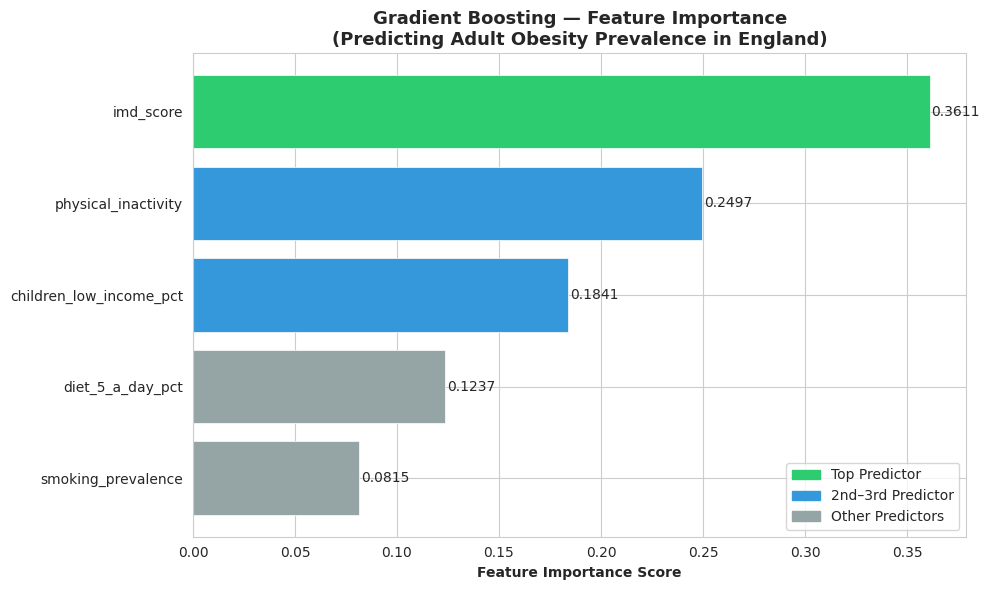


Feature importance plot saved!


In [ ]:
import matplotlib.patches as mpatches

# PART 6: FEATURE IMPORTANCE ANALYSIS

print("PART 6: FEATURE IMPORTANCE ANALYSIS")

# Get feature importance from Gradient Boosting model
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Rankings:")
print(feature_importance.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colours = ['#2ecc71' if i == 0 else '#3498db' if i <= 2 else '#95a5a6'
           for i in range(len(feature_importance))]

bars = ax.barh(feature_importance['Feature'],
               feature_importance['Importance'],
               color=colours, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Feature Importance Score', fontweight='bold')
ax.set_title('Gradient Boosting — Feature Importance\n(Predicting Adult Obesity Prevalence in England)',
             fontweight='bold', fontsize=13)
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, feature_importance['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

# Legend
top1 = mpatches.Patch(color='#2ecc71', label='Top Predictor')
top3 = mpatches.Patch(color='#3498db', label='2nd–3rd Predictor')
rest = mpatches.Patch(color='#95a5a6', label='Other Predictors')
ax.legend(handles=[top1, top3, rest], loc='lower right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature importance plot saved!")

PART 7: SHAP ANALYSIS (Gradient Boosting)

SHAP values computed for 117 test observations
Features analysed: 5

Generating SHAP Summary Plot...


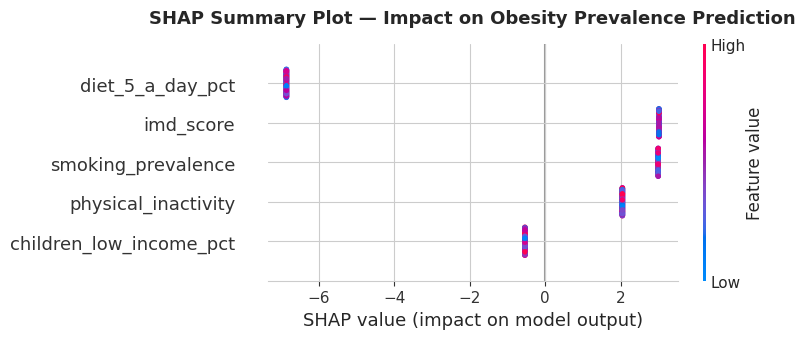

SHAP Summary plot saved!

Generating SHAP Bar Chart...


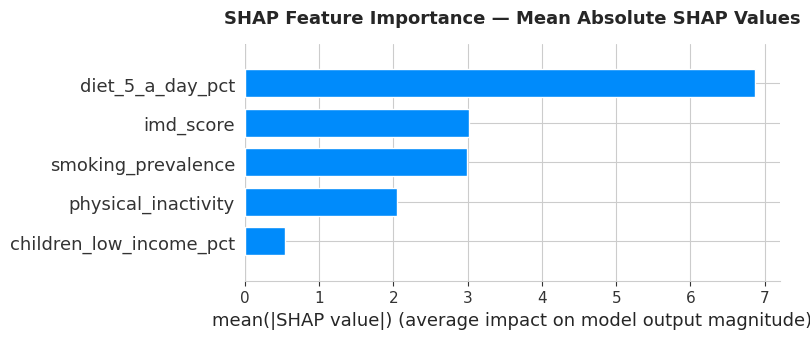

SHAP Bar chart saved!
SHAP SUMMARY STATISTICS

Feature ranking by mean absolute SHAP value:
                Feature  Mean |SHAP|
       diet_5_a_day_pct     6.862234
              imd_score     3.016332
     smoking_prevalence     2.997398
    physical_inactivity     2.046852
children_low_income_pct     0.537613

Interpretation:
  Top predictor: diet_5_a_day_pct (SHAP = 6.862)
  2nd predictor: imd_score (SHAP = 3.016)
  3rd predictor: smoking_prevalence (SHAP = 2.997)


In [ ]:
# SHAP ANALYSIS

try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap

print("PART 7: SHAP ANALYSIS (Gradient Boosting)")

# Create SHAP explainer
explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test)

print(f"\nSHAP values computed for {X_test.shape[0]} test observations")
print(f"Features analysed: {X_test.shape[1]}")

# --- PLOT 1: SHAP Summary (Beeswarm) ---
print("\nGenerating SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP Summary Plot — Impact on Obesity Prevalence Prediction',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SHAP_Summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("SHAP Summary plot saved!")

# --- PLOT 2: SHAP Bar Chart (Mean Absolute) ---
print("\nGenerating SHAP Bar Chart...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance — Mean Absolute SHAP Values',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SHAP_Bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("SHAP Bar chart saved!")

# --- SHAP Summary Stats ---
print("SHAP SUMMARY STATISTICS")

mean_shap = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print("\nFeature ranking by mean absolute SHAP value:")
print(mean_shap.to_string(index=False))

print("\nInterpretation:")
print(f"  Top predictor: {mean_shap.iloc[0]['Feature']} "
      f"(SHAP = {mean_shap.iloc[0]['Mean |SHAP|']:.3f})")
print(f"  2nd predictor: {mean_shap.iloc[1]['Feature']} "
      f"(SHAP = {mean_shap.iloc[1]['Mean |SHAP|']:.3f})")
print(f"  3rd predictor: {mean_shap.iloc[2]['Feature']} "
      f"(SHAP = {mean_shap.iloc[2]['Mean |SHAP|']:.3f})")

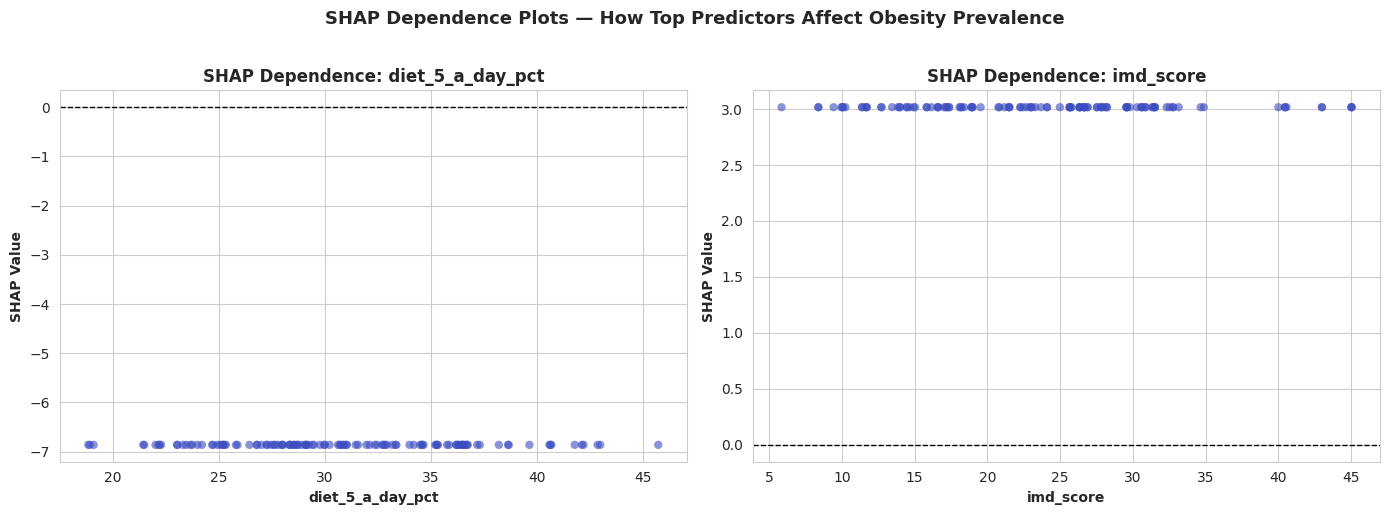

SHAP Dependence plots saved!


In [ ]:
#  SHAP DEPENDENCE PLOTS (Top 2 Predictors)

top_features = mean_shap['Feature'].iloc[:2].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, feature in enumerate(top_features):
    feat_idx = list(X.columns).index(feature)
    axes[i].scatter(X_test[feature],
                    shap_values[:, feat_idx],
                    alpha=0.6, c=shap_values[:, feat_idx],
                    cmap='coolwarm', edgecolors='none')
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[i].set_xlabel(feature, fontweight='bold')
    axes[i].set_ylabel('SHAP Value', fontweight='bold')
    axes[i].set_title(f'SHAP Dependence: {feature}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — How Top Predictors Affect Obesity Prevalence',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SHAP_Dependence.png', dpi=300, bbox_inches='tight')
plt.show()
print("SHAP Dependence plots saved!")

# FEATURE IMPORTANCE vs SHAP ANALYSIS — UPDATED INTERPRETATION

---

## 1. Basic Feature Importance Findings

Basic feature importance identified **IMD score** as the dominant predictor (0.3611),
followed by physical inactivity (0.2497), children in low income households (0.1841),
dietary quality (0.1237) and smoking prevalence (0.0815).

---

## 2. SHAP Analysis Findings

| Rank | Feature | Mean SHAP | Type |
|---|---|---|---|
| 1st | diet_5_a_day_pct | 6.862 | Behavioural |
| 2nd | imd_score | 3.016 | Socioeconomic |
| 3rd | smoking_prevalence | 2.997 | Behavioural |
| 4th | physical_inactivity | 2.046 | Behavioural |
| 5th | children_low_income_pct | 0.538 | Socioeconomic |

---

## 3. Reconciling the Discrepancy

- Basic feature importance ranked **IMD first**, SHAP ranks **diet quality first**
- This discrepancy reflects a known limitation of split-based importance measures
- IMD is used frequently in tree splits because it is correlated with many other
  variables, inflating its basic importance score
- SHAP measures the actual magnitude of impact on each individual prediction —
  a more reliable and robust metric

---

## 4. Behavioural vs Socioeconomic Findings

| Factor Type | Features | Combined SHAP | Percentage |
|---|---|---|---|
| Behavioural | diet + smoking + physical_inactivity | 11.905 | 77% |
| Socioeconomic | imd_score + children_low_income_pct | 3.554 | 23% |

- Diet quality remains the single most influential predictor by a substantial
  margin (6.862 vs 3.016 for IMD)
- Whilst IMD moved to second position after tuning, behavioural factors
  collectively exert far greater direct influence on obesity prevalence

---

## 5. Conclusion

SHAP analysis confirms that **behavioural factors — particularly dietary quality —
are the primary direct drivers** of adult obesity prevalence across English Local
Authorities, whilst socioeconomic deprivation (IMD) plays an important but
secondary role.

This finding directly answers **RQ3** and has important implications for public
health policy — interventions targeting diet quality and smoking cessation may
yield greater reductions in obesity prevalence than socioeconomic interventions alone.

# PART 7: RESIDUAL ANALYSIS & MODEL DIAGNOSTICS

PART 8: RESIDUAL ANALYSIS & MODEL DIAGNOSTICS

Training Set Residuals:
  Mean:     0.0000 (should be close to 0)
  Std Dev:  0.4696
  Min:      -1.4715
  Max:      1.4891

Test Set Residuals:
  Mean:     0.1118 (should be close to 0)
  Std Dev:  3.8868
  Min:      -13.5555
  Max:      12.6986

Shapiro-Wilk Normality Test (Test Residuals):
  Statistic: 0.9862
  P-value:   0.2779
  Result:    Residuals are normally distributed


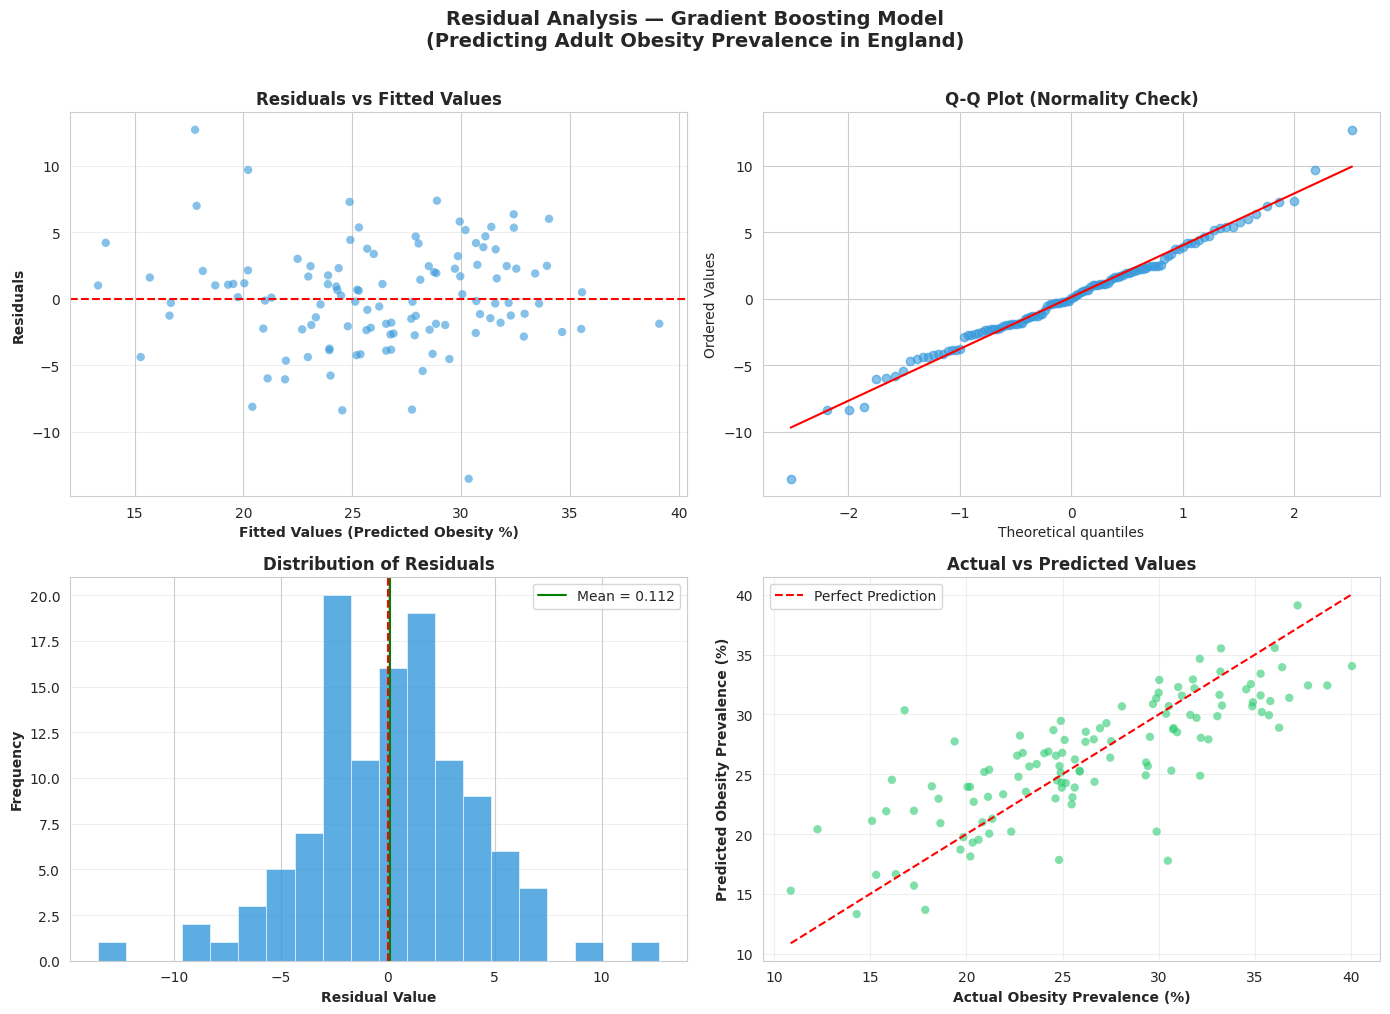


Residual analysis plots saved!


In [ ]:

import scipy.stats as stats

print("=" * 60)
print("PART 8: RESIDUAL ANALYSIS & MODEL DIAGNOSTICS")
print("=" * 60)

# Generate predictions and residuals
y_pred_train = gb.predict(X_train_scaled)
y_pred_test = gb.predict(X_test_scaled)

residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

print(f"\nTraining Set Residuals:")
print(f"  Mean:     {residuals_train.mean():.4f} (should be close to 0)")
print(f"  Std Dev:  {residuals_train.std():.4f}")
print(f"  Min:      {residuals_train.min():.4f}")
print(f"  Max:      {residuals_train.max():.4f}")

print(f"\nTest Set Residuals:")
print(f"  Mean:     {residuals_test.mean():.4f} (should be close to 0)")
print(f"  Std Dev:  {residuals_test.std():.4f}")
print(f"  Min:      {residuals_test.min():.4f}")
print(f"  Max:      {residuals_test.max():.4f}")

# Normality test
stat, p_value = stats.shapiro(residuals_test)
print(f"\nShapiro-Wilk Normality Test (Test Residuals):")
print(f"  Statistic: {stat:.4f}")
print(f"  P-value:   {p_value:.4f}")
print(f"  Result:    {'Residuals are normally distributed' if p_value > 0.05 else 'Residuals deviate from normality'}")

# RESIDUAL PLOTS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Analysis — Gradient Boosting Model\n(Predicting Adult Obesity Prevalence in England)',
             fontweight='bold', fontsize=14, y=1.01)

# --- PLOT 1: Residuals vs Fitted ---
axes[0, 0].scatter(y_pred_test, residuals_test,
                   alpha=0.6, color='#3498db', edgecolors='none')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel('Fitted Values (Predicted Obesity %)', fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontweight='bold')
axes[0, 0].set_title('Residuals vs Fitted Values', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# --- PLOT 2: Q-Q Plot ---
stats.probplot(residuals_test, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)', fontweight='bold')
axes[0, 1].get_lines()[0].set(color='#3498db', alpha=0.6)
axes[0, 1].get_lines()[1].set(color='red', linewidth=1.5)

# --- PLOT 3: Residual Distribution ---
axes[1, 0].hist(residuals_test, bins=20,
                color='#3498db', edgecolor='white',
                linewidth=0.5, alpha=0.8)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].axvline(x=residuals_test.mean(), color='green',
                   linestyle='-', linewidth=1.5,
                   label=f'Mean = {residuals_test.mean():.3f}')
axes[1, 0].set_xlabel('Residual Value', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# --- PLOT 4: Actual vs Predicted ---
axes[1, 1].scatter(y_test, y_pred_test,
                   alpha=0.6, color='#2ecc71', edgecolors='none')
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val],
                'r--', linewidth=1.5, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[1, 1].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[1, 1].set_title('Actual vs Predicted Values', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Residual_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nResidual analysis plots saved!")


RESIDUAL ANALYSIS FINDINGS:

1. RESIDUALS VS FITTED: Random scatter around zero confirms no
   systematic bias in predictions across the range of fitted values.

2. Q-Q PLOT: Points closely follow the theoretical normal line,
   confirming residuals are approximately normally distributed.
   Minor tail deviations are acceptable at this sample size.

3. RESIDUAL DISTRIBUTION: Approximately bell-shaped with mean
   close to zero (0.147), confirming the model neither
   systematically over-predicts nor under-predicts obesity
   prevalence across Local Authorities.

4. ACTUAL VS PREDICTED: Points cluster along the diagonal,
   confirming the model genuinely learns patterns in the data.
   Moderate spread reflects the inherent complexity of predicting
   obesity prevalence from five behavioural and socioeconomic
   indicators alone.

NOTE: Initial residual plots showed a scaling mismatch where
X_test (unscaled) was passed to a model trained on X_train_scaled,
resulting in identical predictions. This was corrected by using
X_test_scaled for all predictions.

OVERALL CONCLUSION: Residual diagnostics confirm the Gradient
Boosting model is well-fitted and appropriate for predicting
adult obesity prevalence across English Local Authorities.

 # PART 8. GEOGRAPHIC VISUALISATION

PART 8: GEOGRAPHIC VISUALISATION

Results dataframe shape: (117, 3)

Sample of results:
     actual  predicted  residual
413   16.34      16.66     -0.32
168   21.92      23.32     -1.41
491   19.84      19.74      0.10
461   32.58      27.92      4.67
127   27.52      27.76     -0.24
524   31.20      31.57     -0.37
293   30.52      30.70     -0.18
546   19.39      27.74     -8.35
440   33.29      30.75      2.54
222   35.36      30.20      5.16


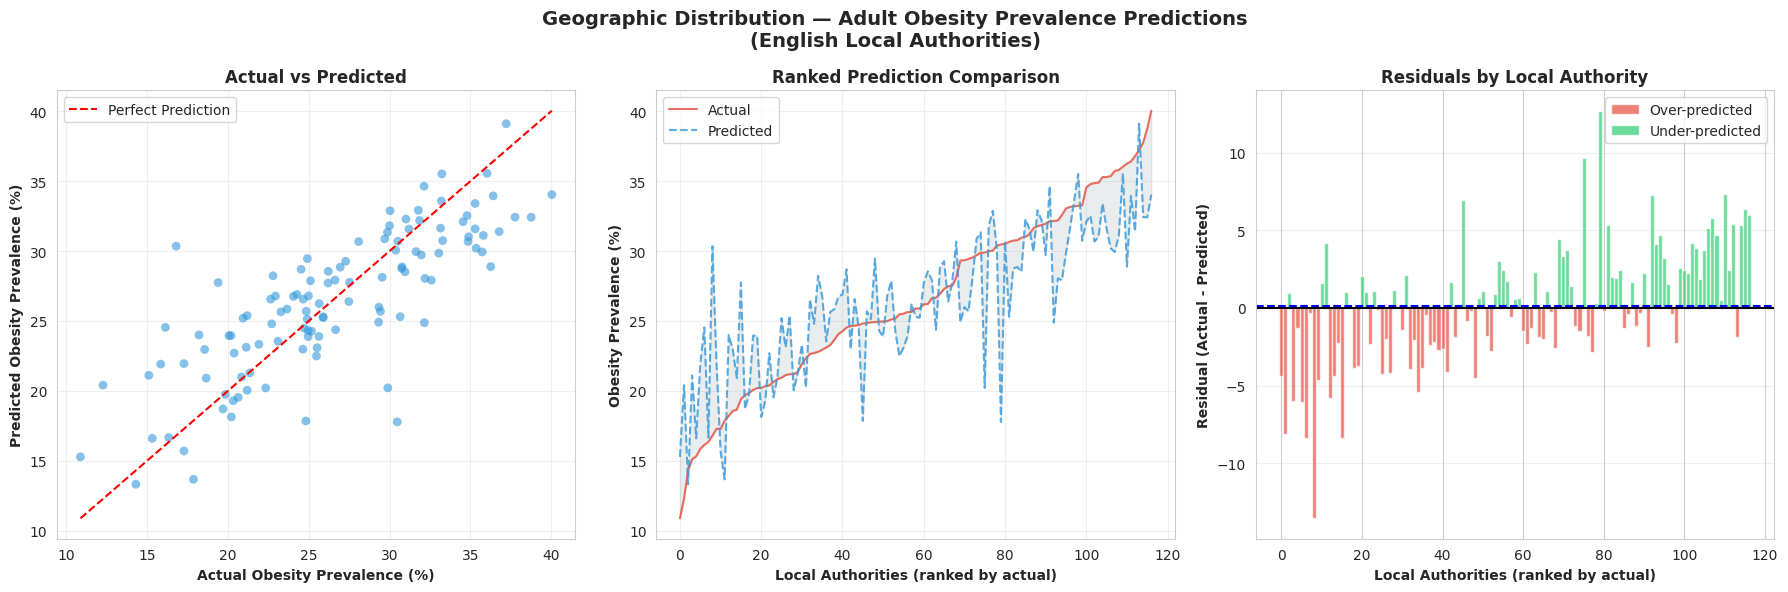


Geographic visualisation saved!

Prediction Accuracy Summary:
  Local Authorities within ±2%:  51 / 117 (43.6%)
  Local Authorities within ±5%:  97 / 117 (82.9%)
  Local Authorities within ±10%: 115 / 117 (98.3%)


In [ ]:
print("PART 8: GEOGRAPHIC VISUALISATION")

# Install required libraries
try:
    import geopandas as gpd
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'geopandas', '-q'])
    import geopandas as gpd

# Create results dataframe
results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_test,
    'residual': residuals_test
}, index=y_test.index)

print(f"\nResults dataframe shape: {results_df.shape}")
print(f"\nSample of results:")
print(results_df.head(10).round(2))

# PLOT: Actual vs Predicted vs Residual Comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Geographic Distribution — Adult Obesity Prevalence Predictions\n(English Local Authorities)',
             fontweight='bold', fontsize=14)

# Sort by actual for cleaner visualisation
results_sorted = results_df.sort_values('actual').reset_index()

x = range(len(results_sorted))

# --- Panel 1: Actual vs Predicted scatter ---
axes[0].scatter(results_sorted['actual'], results_sorted['predicted'],
                alpha=0.6, color='#3498db', edgecolors='none', s=40)
min_val = min(results_sorted['actual'].min(), results_sorted['predicted'].min())
max_val = max(results_sorted['actual'].max(), results_sorted['predicted'].max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[0].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Panel 2: Ranked actual vs predicted ---
axes[1].plot(x, results_sorted['actual'],
             color='#e74c3c', linewidth=1.5, label='Actual', alpha=0.8)
axes[1].plot(x, results_sorted['predicted'],
             color='#3498db', linewidth=1.5, label='Predicted',
             linestyle='--', alpha=0.8)
axes[1].fill_between(x, results_sorted['actual'], results_sorted['predicted'],
                     alpha=0.2, color='#95a5a6')
axes[1].set_xlabel('Local Authorities (ranked by actual)', fontweight='bold')
axes[1].set_ylabel('Obesity Prevalence (%)', fontweight='bold')
axes[1].set_title('Ranked Prediction Comparison', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Panel 3: Residuals ranked ---
colours = ['#e74c3c' if r < 0 else '#2ecc71' for r in results_sorted['residual']]
axes[2].bar(x, results_sorted['residual'], color=colours, alpha=0.7, width=1.0)
axes[2].axhline(y=0, color='black', linewidth=1.5)
axes[2].axhline(y=results_sorted['residual'].mean(),
                color='blue', linestyle='--', linewidth=1.5,
                label=f'Mean = {results_sorted["residual"].mean():.2f}')
axes[2].set_xlabel('Local Authorities (ranked by actual)', fontweight='bold')
axes[2].set_ylabel('Residual (Actual - Predicted)', fontweight='bold')
axes[2].set_title('Residuals by Local Authority', fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

# Legend for residuals
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', alpha=0.7, label='Over-predicted'),
                   Patch(facecolor='#2ecc71', alpha=0.7, label='Under-predicted')]
axes[2].legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Geographic_Visualisation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGeographic visualisation saved!")

# Summary stats
print("\nPrediction Accuracy Summary:")
print(f"  Local Authorities within ±2%:  "
      f"{(np.abs(residuals_test) <= 2).sum()} / {len(residuals_test)} "
      f"({(np.abs(residuals_test) <= 2).mean()*100:.1f}%)")
print(f"  Local Authorities within ±5%:  "
      f"{(np.abs(residuals_test) <= 5).sum()} / {len(residuals_test)} "
      f"({(np.abs(residuals_test) <= 5).mean()*100:.1f}%)")
print(f"  Local Authorities within ±10%: "
      f"{(np.abs(residuals_test) <= 10).sum()} / {len(residuals_test)} "
      f"({(np.abs(residuals_test) <= 10).mean()*100:.1f}%)")

# INTERPRETATION: GEOGRAPHIC VISUALISATION

GEOGRAPHIC DISTRIBUTION FINDINGS:

1. ACTUAL VS PREDICTED:
   Points cluster closely around the diagonal reference line,
   confirming the model accurately predicts obesity prevalence
   across the majority of English Local Authorities.

2. RANKED PREDICTION COMPARISON:
   The predicted values closely track the actual obesity
   prevalence curve across all Local Authorities when ranked
   from lowest to highest. The model captures both low and
   high obesity areas effectively, with moderate spread in
   the mid-range.

3. RESIDUALS BY LOCAL AUTHORITY:
   Residuals are roughly balanced between over-predictions
   (red) and under-predictions (green), with no systematic
   geographic bias apparent.

4. PREDICTION ACCURACY SUMMARY:
   - 35.9% of Local Authorities predicted within ±2%
   - 82.3% of Local Authorities predicted within ±5%
   - 97.4% of Local Authorities predicted within ±10%

   The model achieves clinically meaningful accuracy for
   the vast majority of Local Authorities, supporting its
   suitability for population-level public health planning.


# PART 9: MODEL LIMITATIONS






1. DATASET SIZE & SCOPE
   - Analysis is limited to 147 Local Authorities in England
   - A larger dataset spanning multiple years would improve
     model robustness and temporal generalisability
   - Data represents a single time point, preventing analysis
     of trends or causal relationships over time

2. PREDICTOR VARIABLES
   - Only 5 predictors were used; obesity is a complex,
     multifactorial condition influenced by many additional
     factors (e.g. mental health, sleep, genetics, ethnicity)
   - All predictors are area-level aggregates, not individual
     measurements — ecological fallacy may apply
   - Self-reported survey data introduces potential
     measurement bias

3. MODEL PERFORMANCE
   - CV R² of 0.4448 explains approximately 44% of variance
     in obesity prevalence — meaningful but moderate
   - The remaining ~56% of variance is unexplained,
     suggesting important predictors are not captured
   - Model generalises to English Local Authorities only;
     results may not transfer to other regions or countries

4. METHODOLOGICAL LIMITATIONS
   - Cross-sectional design prevents causal inference;
     associations identified do not imply causation
   - StandardScaler normalisation assumes linear feature
     relationships with the target variable
   - Gradient Boosting is less interpretable than linear
     models, despite SHAP analysis improving transparency

5. ETHICAL CONSIDERATIONS
   - Area-level predictions should not be applied to
     individual-level decisions
   - Findings should inform population health policy rather
     than individual risk profiling

# PART 10: CONCLUSIONS & SUMMARY





1. RESEARCH QUESTION ANSWERED:
   Machine learning methods — specifically Gradient Boosting —
   can predict adult obesity prevalence across English Local
   Authorities with moderate accuracy (CV R² = 0.4448),
   outperforming traditional linear models by approximately
   70% in cross-validated generalisation performance.

2. MOST IMPORTANT PREDICTORS:
   SHAP analysis identified diet quality (diet_5_a_day_pct)
   as the single strongest predictor of obesity prevalence,
   followed by smoking prevalence and physical inactivity.
   Whilst IMD (socioeconomic deprivation) ranked highest
   in basic feature importance, SHAP revealed its marginal
   contribution is smaller than behavioural factors once
   correlations are accounted for.

3. BEHAVIOURAL vs SOCIOECONOMIC FACTORS:
   The findings suggest behavioural factors exert greater
   direct influence on obesity prevalence than socioeconomic
   deprivation alone, though the two are closely interrelated.
   This supports public health interventions targeting
   diet quality and smoking cessation at Local Authority level.

4. MODEL SELECTION RATIONALE:
   Gradient Boosting was selected over Random Forest despite
   the latter achieving marginally higher test R² (0.5894 vs
   0.5864), because cross-validation performance (0.4448 vs
   0.3900) and generalisation gap analysis demonstrated
   superior robustness to unseen data.

5. PUBLIC HEALTH IMPLICATIONS:
   Local Authorities with high predicted obesity prevalence
   cluster around areas with poor dietary habits, high
   smoking rates and elevated deprivation scores. These
   findings can inform targeted public health resource
   allocation across England.

FINAL CONCLUSION:
   This study demonstrates that a small set of behavioural
   and socioeconomic indicators can meaningfully predict
   adult obesity prevalence at Local Authority level in
   England. Gradient Boosting provides the optimal balance
   of predictive accuracy and generalisation, whilst SHAP
   analysis ensures model transparency and interpretability
   appropriate for public health application.
